In [1]:
# imports
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#2 Locate working dir
WORKING_DIR = Path("../data/working_images")

working_images = sorted(
    [
        p for p in WORKING_DIR.iterdir()
        if p.is_file()
        and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]
)

print("Working image directory:")
print(WORKING_DIR.resolve())

print("\nNumber of working images:", len(working_images))

print("\nFirst 10 images:")
for i, path in enumerate(working_images[:10]):
    print(i, path.name)

Working image directory:
C:\Users\nsvin\DSAI\GerrardHall3D\data\working_Images

Number of working images: 100

First 10 images:
0 IMG_2331.JPG
1 IMG_2332.JPG
2 IMG_2333.JPG
3 IMG_2334.JPG
4 IMG_2335.JPG
5 IMG_2336.JPG
6 IMG_2337.JPG
7 IMG_2338.JPG
8 IMG_2339.JPG
9 IMG_2340.JPG


In [3]:
#3 Select 2 different images
img_path1 = working_images[0]
img_path2 = working_images[1]

print("Image 1:", img_path1.name)
print("Image 2:", img_path2.name)

Image 1: IMG_2331.JPG
Image 2: IMG_2332.JPG


In [4]:
#4 Verify 2 images
img1 = cv2.imread(str(img_path1))
img2 = cv2.imread(str(img_path2))

print("Image 1 shape:", img1.shape)
print("Image 2 shape:", img2.shape)

print("Identical pixels:", np.array_equal(img1, img2))

Image 1 shape: (936, 1404, 3)
Image 2 shape: (936, 1404, 3)
Identical pixels: False


In [5]:
#5 Load saved SIFT descriptors
FEATURE_DIR = Path("../features")

des1 = np.load(
    FEATURE_DIR / f"{img_path1.stem}_descriptors.npy"
)

des2 = np.load(
    FEATURE_DIR / f"{img_path2.stem}_descriptors.npy"
)

print("Image 1:", img_path1.name)
print("Image 2:", img_path2.name)

print("Image 1 descriptors:", des1.shape)
print("Image 2 descriptors:", des2.shape)


Image 1: IMG_2331.JPG
Image 2: IMG_2332.JPG
Image 1 descriptors: (9292, 128)
Image 2 descriptors: (9839, 128)


In [6]:
#6 Create the feature matcher
FLANN_INDEX_KDTREE = 1

index_params = dict(
    algorithm=FLANN_INDEX_KDTREE,
    trees=5
)

search_params = dict(
    checks=50
)

flann = cv2.FlannBasedMatcher(
    index_params,
    search_params
)

print("FLANN matcher created successfully.")

FLANN matcher created successfully.


In [7]:
#7 Find 2 nearest matches
matches = flann.knnMatch(
    des1.astype(np.float32),
    des2.astype(np.float32),
    k=2
)

print("Number of descriptor queries:", len(matches))


Number of descriptor queries: 9292


In [8]:
#8 Lowe's Ratio Test
ratio_threshold = 0.7

good_matches = []

for m, n in matches:
    if m.distance < ratio_threshold * n.distance:
        good_matches.append(m)

print("Candidate matches:", len(matches))
print("Good matches:", len(good_matches))

Candidate matches: 9292
Good matches: 1051


In [9]:
#9 Visualize the 1051 matches
kp1_array = np.load(
    FEATURE_DIR / f"{img_path1.stem}_keypoints.npy"
)

kp2_array = np.load(
    FEATURE_DIR / f"{img_path2.stem}_keypoints.npy"
)

print("Image 1 keypoints:", kp1_array.shape)
print("Image 2 keypoints:", kp2_array.shape)

Image 1 keypoints: (9292, 5)
Image 2 keypoints: (9839, 5)


In [10]:
#10 Convert them back to OpenCV keypoints

def array_to_keypoints(arr):
    keypoints = []

    for x, y, size, angle, response in arr:
        kp = cv2.KeyPoint(
            float(x),
            float(y),
            float(size),
            float(angle),
            float(response)
        )
        keypoints.append(kp)

    return keypoints

In [11]:
keypoints1 = array_to_keypoints(kp1_array)
keypoints2 = array_to_keypoints(kp2_array)

print("Reconstructed keypoints:",
      len(keypoints1),
      len(keypoints2))

Reconstructed keypoints: 9292 9839


In [13]:
#11 Draw the matches
display_matches = sorted(
    good_matches,
    key=lambda m: m.distance
)[:100]

match_image = cv2.drawMatches(
    img1,
    keypoints1,
    img2,
    keypoints2,
    display_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

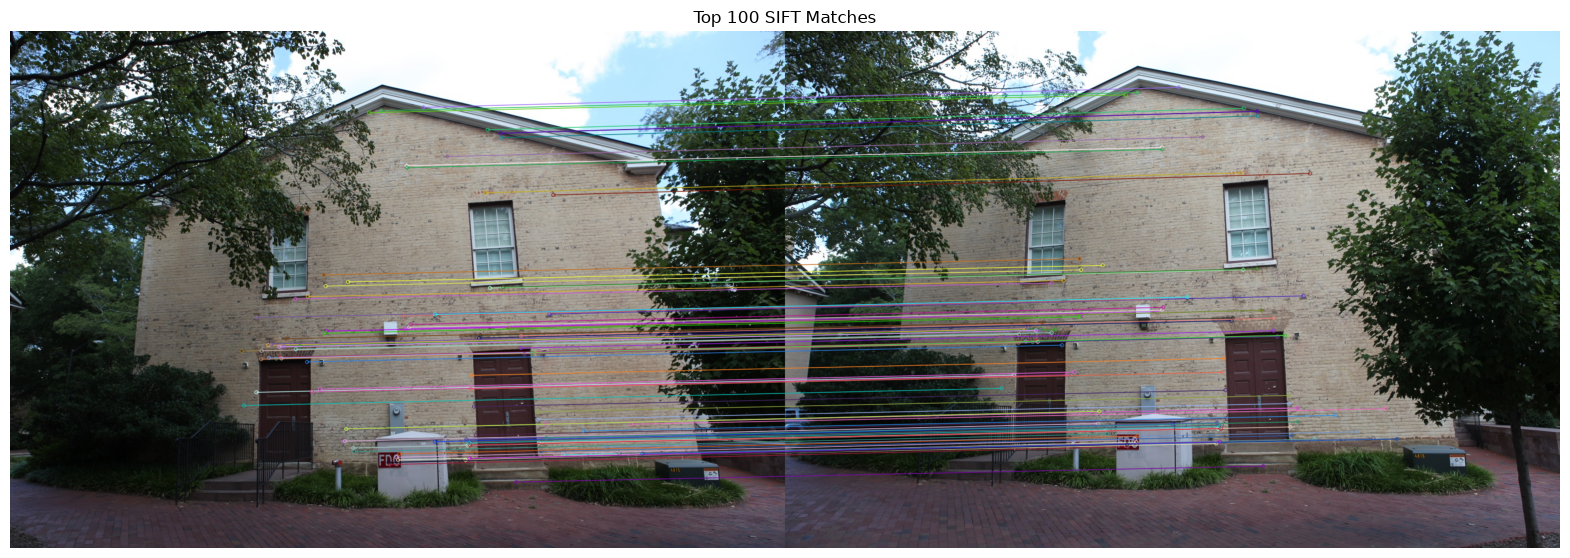

In [14]:
plt.figure(figsize=(20, 10))

plt.imshow(
    cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB)
)

plt.title("Top 100 SIFT Matches")

plt.axis("off")
plt.show()

In [15]:
#12 Extract matched point coordinates
pts1 = np.float32(
    [keypoints1[m.queryIdx].pt for m in good_matches]
)

pts2 = np.float32(
    [keypoints2[m.trainIdx].pt for m in good_matches]
)

print("pts1 shape:", pts1.shape)
print("pts2 shape:", pts2.shape)

pts1 shape: (1051, 2)
pts2 shape: (1051, 2)


In [16]:
#13 Estimate the Fundamental Matrix using RANSAC
F, mask = cv2.findFundamentalMat(
    pts1,
    pts2,
    method=cv2.FM_RANSAC,
    ransacReprojThreshold=1.0,
    confidence=0.99
)

print("Fundamental Matrix F:")
print(F)

print("\nF shape:", F.shape)

Fundamental Matrix F:
[[ 1.21911428e-06 -2.51476115e-05 -8.75904291e-04]
 [-4.81270396e-05  1.17536589e-05  9.79942736e-01]
 [ 4.39772620e-02 -9.40978270e-01  1.00000000e+00]]

F shape: (3, 3)


In [17]:
# Count RANSAC inliers
inlier_mask = mask.ravel().astype(bool)

num_inliers = np.sum(inlier_mask)
num_outliers = len(inlier_mask) - num_inliers

print("Total matches :", len(pts1))
print("RANSAC inliers:", num_inliers)
print("Outliers      :", num_outliers)


Total matches : 1051
RANSAC inliers: 911
Outliers      : 140


In [18]:
# Seperate outliers
inlier_matches = [
    m for i, m in enumerate(good_matches)
    if inlier_mask[i]
]

outlier_matches = [
    m for i, m in enumerate(good_matches)
    if not inlier_mask[i]
]

print("Inlier matches :", len(inlier_matches))
print("Outlier matches:", len(outlier_matches))

Inlier matches : 911
Outlier matches: 140


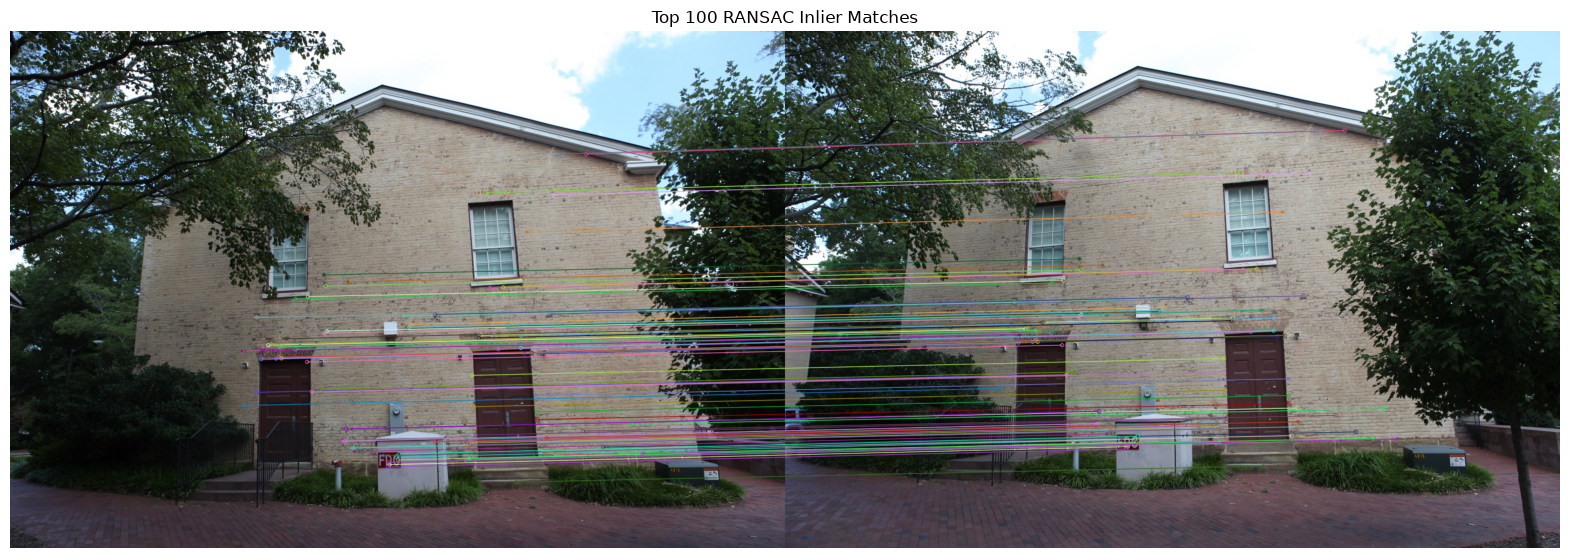

In [19]:
# Visualize only inliers
display_inliers = sorted(
    inlier_matches,
    key=lambda m: m.distance
)[:100]

inlier_image = cv2.drawMatches(
    img1,
    keypoints1,
    img2,
    keypoints2,
    display_inliers,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(20, 10))

plt.imshow(
    cv2.cvtColor(inlier_image, cv2.COLOR_BGR2RGB)
)

plt.title("Top 100 RANSAC Inlier Matches")

plt.axis("off")
plt.show()

In [20]:
# Epipolar Lines
# Select a few geometrically verified matches
num_points = 10

selected_matches = inlier_matches[:num_points]

print("Number of selected matches:", len(selected_matches))

Number of selected matches: 10


In [21]:
# Extract the coordinates
pts1_epi = np.float32(
    [keypoints1[m.queryIdx].pt for m in selected_matches]
)

pts2_epi = np.float32(
    [keypoints2[m.trainIdx].pt for m in selected_matches]
)

print("Image 1 points:", pts1_epi.shape)
print("Image 2 points:", pts2_epi.shape)

Image 1 points: (10, 2)
Image 2 points: (10, 2)


In [26]:
# Calculate epipolar lines for points in image1
lines2 = cv2.computeCorrespondEpilines(
    pts1_epi.reshape(-1, 1, 2),
    1,
    F
)

lines2 = lines2.reshape(-1, 3)

In [27]:
# Calculate epipolar lines for points in image2

lines1 = cv2.computeCorrespondEpilines(
    pts2_epi.reshape(-1, 1, 2),
    2,
    F
)

lines1 = lines1.reshape(-1, 3)

In [28]:
# Draw the epipolar lines
def draw_epilines(img, lines, points):
    """
    Draw epipolar lines and corresponding points.
    """

    output = img.copy()

    h, w = output.shape[:2]

    for line, point in zip(lines, points):

        a, b, c = line

        if abs(b) > 1e-8:
            x0 = 0
            y0 = int(-(c + a * x0) / b)

            x1 = w - 1
            y1 = int(-(c + a * x1) / b)

        else:
            x0 = int(-c / a)
            x1 = x0
            y0 = 0
            y1 = h - 1

        cv2.line(
            output,
            (x0, y0),
            (x1, y1),
            (255, 0, 0),
            2
        )

        x, y = point

        cv2.circle(
            output,
            (int(x), int(y)),
            8,
            (0, 255, 0),
            -1
        )

    return output

In [30]:
img1_epi = draw_epilines(
    img1,
    lines1,
    pts1_epi
)

img2_epi = draw_epilines(
    img2,
    lines2,
    pts2_epi
)

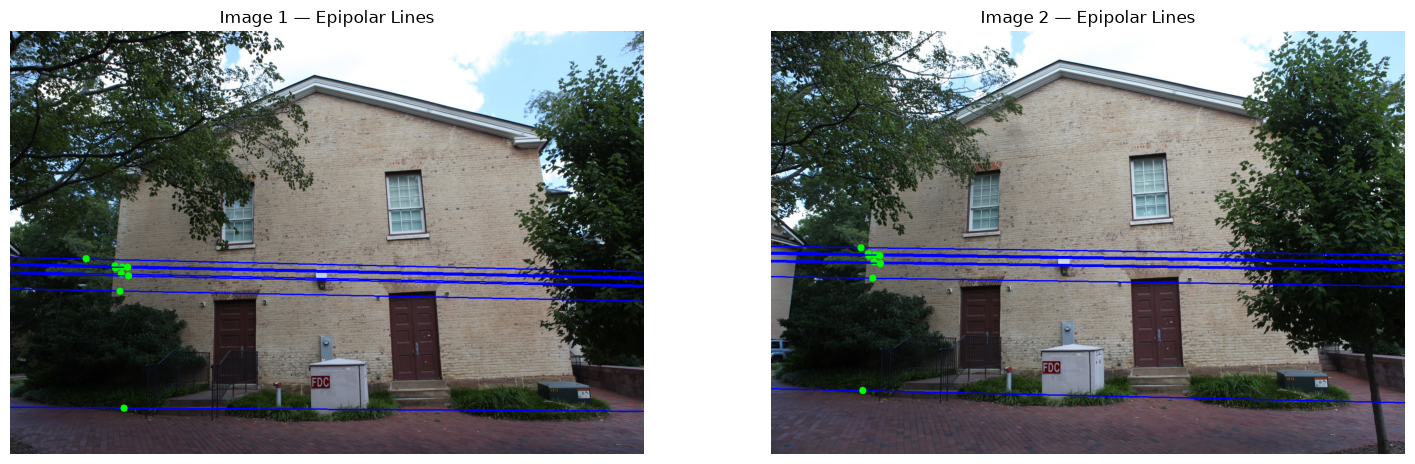

In [31]:
# Display
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)

plt.imshow(
    cv2.cvtColor(img1_epi, cv2.COLOR_BGR2RGB)
)

plt.title("Image 1 — Epipolar Lines")
plt.axis("off")

plt.subplot(1, 2, 2)

plt.imshow(
    cv2.cvtColor(img2_epi, cv2.COLOR_BGR2RGB)
)

plt.title("Image 2 — Epipolar Lines")
plt.axis("off")

plt.show()

In [32]:
# Extract RANSAC inliers
pts1_inliers = pts1[inlier_mask]
pts2_inliers = pts2[inlier_mask]

print("Inlier points - Image 1:", pts1_inliers.shape)
print("Inlier points - Image 2:", pts2_inliers.shape)

Inlier points - Image 1: (911, 2)
Inlier points - Image 2: (911, 2)


In [33]:
# Normalize function
def normalize_points(points):
    """
    Normalize 2D points for the normalized Eight-Point Algorithm.

    Parameters
    ----------
    points : ndarray of shape (N, 2)

    Returns
    -------
    normalized_points : ndarray of shape (N, 2)
    T : ndarray of shape (3, 3)
    """

    centroid = np.mean(points, axis=0)

    centered = points - centroid

    distances = np.sqrt(
        np.sum(centered ** 2, axis=1)
    )

    mean_distance = np.mean(distances)

    scale = np.sqrt(2) / mean_distance

    T = np.array([
        [scale, 0, -scale * centroid[0]],
        [0, scale, -scale * centroid[1]],
        [0, 0, 1]
    ])

    # Convert to homogeneous coordinates
    points_h = np.hstack([
        points,
        np.ones((points.shape[0], 1))
    ])

    normalized_h = (T @ points_h.T).T

    normalized_points = (
        normalized_h[:, :2] /
        normalized_h[:, 2:3]
    )

    return normalized_points, T

In [34]:
#Normalize both images

pts1_norm, T1 = normalize_points(pts1_inliers)
pts2_norm, T2 = normalize_points(pts2_inliers)

print("Normalized Image 1:", pts1_norm.shape)
print("Normalized Image 2:", pts2_norm.shape)

print("\nT1:")
print(T1)

print("\nT2:")
print(T2)

Normalized Image 1: (911, 2)
Normalized Image 2: (911, 2)

T1:
[[ 0.00551278  0.         -4.34617498]
 [ 0.          0.00551278 -3.29891851]
 [ 0.          0.          1.        ]]

T2:
[[ 0.00551796  0.         -4.12924526]
 [ 0.          0.00551796 -3.13045884]
 [ 0.          0.          1.        ]]


In [35]:
# Construct Matrix
A = np.zeros((len(pts1_norm), 9))

for i, ((x1, y1), (x2, y2)) in enumerate(
    zip(pts1_norm, pts2_norm)
):
    A[i] = [
        x2 * x1,
        x2 * y1,
        x2,
        y2 * x1,
        y2 * y1,
        y2,
        x1,
        y1,
        1
    ]

print("A shape:", A.shape)

A shape: (911, 9)


In [36]:
U, S, Vt = np.linalg.svd(A)

print("U shape :", U.shape)
print("S shape :", S.shape)
print("Vt shape:", Vt.shape)

print("\nSingular values:")
print(S)

U shape : (911, 911)
S shape : (9,)
Vt shape: (9, 9)

Singular values:
[8.45104525e+01 5.87326522e+01 5.25006470e+01 2.89121158e+01
 2.24432995e+01 1.58427550e+01 1.05229553e+00 2.23006405e-01
 2.41706231e-02]


In [37]:
f = Vt[-1]

print("Solution vector f:")
print(f)

print("\nSmallest singular value:", S[-1])

Solution vector f:
[-1.33308896e-04  6.51119535e-03  2.47552492e-02  3.01348133e-03
 -1.97780701e-03 -7.04032025e-01 -2.61645247e-02  7.09214338e-01
  1.05803319e-03]

Smallest singular value: 0.024170623062209313


In [38]:
# Construct the raw Fundamental Matrix

F_raw = f.reshape(3, 3)

print("Raw Fundamental Matrix:")
print(F_raw)
print("\nRank of F_raw:", np.linalg.matrix_rank(F_raw))

U_F, S_F, Vt_F = np.linalg.svd(F_raw)
print("Singular values of F_raw:")
print(S_F)

S_F[2] = 0
F_rank2 = U_F @ np.diag(S_F) @ Vt_F
print("\nRank-2 Fundamental Matrix:")
print(F_rank2)
print("\nRank of F_rank2:",
      np.linalg.matrix_rank(F_rank2))


Raw Fundamental Matrix:
[[-1.33308896e-04  6.51119535e-03  2.47552492e-02]
 [ 3.01348133e-03 -1.97780701e-03 -7.04032025e-01]
 [-2.61645247e-02  7.09214338e-01  1.05803319e-03]]

Rank of F_raw: 3
Singular values of F_raw:
[7.10221135e-01 7.03978618e-01 2.09975435e-04]

Rank-2 Fundamental Matrix:
[[-3.43001731e-04  6.50346117e-03  2.47543756e-02]
 [ 3.00611121e-03 -1.97807884e-03 -7.04032056e-01]
 [-2.61626224e-02  7.09214408e-01  1.05804111e-03]]

Rank of F_rank2: 2


In [39]:
# Denormalize the Fundamental Matrix

F_manual = T2.T @ F_rank2 @ T1

print("Fundamental Matrix from our Eight-Point Algorithm:")
print(F_manual)

print("\nRank of F_manual:",
      np.linalg.matrix_rank(F_manual))

Fundamental Matrix from our Eight-Point Algorithm:
[[-1.04338710e-08  1.97830707e-07  2.64350879e-05]
 [ 9.14437853e-08 -6.01717649e-08 -3.92090826e-03]
 [-1.88298733e-04  3.79583453e-03 -2.02420649e-02]]

Rank of F_manual: 2


In [40]:
# Compare with OpenCV's Fundamental Matrix

def normalize_F(F):
    norm = np.linalg.norm(F)

    if norm == 0:
        raise ValueError("Cannot normalize a zero matrix.")

    return F / norm


F_manual_norm = normalize_F(F_manual)
F_opencv_norm = normalize_F(F)

print("Normalized manual F:")
print(F_manual_norm)

print("\nNormalized OpenCV F:")
print(F_opencv_norm)

Normalized manual F:
[[-4.97664617e-07  9.43593637e-06  1.26087507e-03]
 [ 4.36159660e-06 -2.87001423e-06 -1.87015663e-01]
 [-8.98128954e-03  1.81050018e-01 -9.65486292e-01]]

Normalized OpenCV F:
[[ 7.22437279e-07 -1.49022716e-05 -5.19053812e-04]
 [-2.85196952e-05  6.96512339e-06  5.80706155e-01]
 [ 2.60605705e-02 -5.57616127e-01  5.92591928e-01]]


In [41]:
# Check if similar geometry
error_same = np.linalg.norm(
    F_manual_norm - F_opencv_norm
)

error_flipped = np.linalg.norm(
    F_manual_norm + F_opencv_norm
)

print("Difference without sign flip:", error_same)
print("Difference with sign flip    :", error_flipped)


Difference without sign flip: 1.8878197219974262
Difference with sign flip    : 0.6604064636551952


In [42]:
# Better test: epipolar error

pts1_h = np.hstack([
    pts1_inliers,
    np.ones((len(pts1_inliers), 1))
])

pts2_h = np.hstack([
    pts2_inliers,
    np.ones((len(pts2_inliers), 1))
])

errors_manual = np.abs(
    np.sum(
        pts2_h * (F_manual @ pts1_h.T).T,
        axis=1
    )
)

errors_opencv = np.abs(
    np.sum(
        pts2_h * (F @ pts1_h.T).T,
        axis=1
    )
)

print("Manual F:")
print("Mean epipolar error:", np.mean(errors_manual))
print("Median epipolar error:", np.median(errors_manual))

print("\nOpenCV F:")
print("Mean epipolar error:", np.mean(errors_opencv))
print("Median epipolar error:", np.median(errors_opencv))


Manual F:
Mean epipolar error: 0.0006810760131615577
Median epipolar error: 0.0004715612024708271

OpenCV F:
Mean epipolar error: 0.2892474678756313
Median epipolar error: 0.2556894979642266


In [43]:
# Compute Sampson distance

def sampson_errors(F, pts1, pts2):
    
    # Homogeneous coordinates
    pts1_h = np.hstack([
        pts1,
        np.ones((len(pts1), 1))
    ])
    
    pts2_h = np.hstack([
        pts2,
        np.ones((len(pts2), 1))
    ])
    
    # F x1
    Fx1 = (F @ pts1_h.T).T
    
    # F^T x2
    Ftx2 = (F.T @ pts2_h.T).T
    
    # x2^T F x1
    numerator = np.sum(
        pts2_h * Fx1,
        axis=1
    ) ** 2
    
    denominator = (
        Fx1[:, 0] ** 2 +
        Fx1[:, 1] ** 2 +
        Ftx2[:, 0] ** 2 +
        Ftx2[:, 1] ** 2
    )
    
    return numerator / (denominator + 1e-12)

In [44]:
sampson_manual = sampson_errors(
    F_manual,
    pts1_inliers,
    pts2_inliers
)

sampson_opencv = sampson_errors(
    F,
    pts1_inliers,
    pts2_inliers
)

print("Manual Eight-Point F")
print("Mean Sampson error  :", np.mean(sampson_manual))
print("Median Sampson error:", np.median(sampson_manual))

print("\nOpenCV RANSAC F")
print("Mean Sampson error  :", np.mean(sampson_opencv))
print("Median Sampson error:", np.median(sampson_opencv))

Manual Eight-Point F
Mean Sampson error  : 0.031045869298077674
Median Sampson error: 0.007345564467353316

OpenCV RANSAC F
Mean Sampson error  : 0.07064095146038507
Median Sampson error: 0.036104709322664574


# Phase 2 — Camera Calibration

In [47]:
# Inspect EXIF metadata

from PIL import Image
from PIL.ExifTags import TAGS

original_image = sorted(
    list(IMAGE_DIR.glob("*.JPG")) +
    list(IMAGE_DIR.glob("*.jpg"))
)[0]

print("Image:", original_image.name)

img_pil = Image.open(original_image)

exif_data = img_pil.getexif()

print("Number of EXIF entries:", len(exif_data))

for tag_id, value in exif_data.items():
    
    tag = TAGS.get(tag_id, tag_id)
    
    print(f"{tag}: {value}")

Image: IMG_2331.JPG
Number of EXIF entries: 12
GPSInfo: 8672
ResolutionUnit: 2
ExifOffset: 360
Make: Canon
Model: Canon EOS 5D Mark II
YResolution: 72.0
Orientation: 1
DateTime: 2015:09:19 14:09:50
YCbCrPositioning: 2
Copyright: 
XResolution: 72.0
Artist: 


In [46]:
from pathlib import Path

IMAGE_DIR = Path("../data/images")

In [48]:
#Read EXIF subdir

from PIL.ExifTags import TAGS

exif_data = img_pil.getexif()

for tag_id, value in exif_data.items():
    
    tag = TAGS.get(tag_id, tag_id)
    
    if tag == "ExifOffset":
        print("ExifOffset found:", value)

ExifOffset found: 360


In [52]:
#Safer pillow to access nested EXIF info

from PIL.ExifTags import IFD

exif_ifd = exif_data.get_ifd(IFD.Exif)

print("Number of EXIF sub-tags:", len(exif_ifd))

for tag_id, value in exif_ifd.items():
    tag = TAGS.get(tag_id, tag_id)
    print(f"{tag}: {value}")

Number of EXIF sub-tags: 31
ExifVersion: b'0221'
ComponentsConfiguration: b'\x01\x02\x03\x00'
ShutterSpeedValue: 7.0
DateTimeOriginal: 2015:09:19 14:09:50
DateTimeDigitized: 2015:09:19 14:09:50
ApertureValue: 5.0
ExposureBiasValue: 0.0
MeteringMode: 5
UserComment: b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\

In [53]:
from PIL.ExifTags import TAGS, IFD

# Get nested EXIF data
exif_ifd = exif_data.get_ifd(IFD.Exif)

# Important camera parameters
for name in ["FocalLength", "FocalLengthIn35mmFilm", "PixelXDimension",
             "PixelYDimension", "LensModel"]:
    
    tag_id = next((k for k, v in TAGS.items() if v == name), None)
    
    if tag_id in exif_ifd:
        print(f"{name}: {exif_ifd[tag_id]}")

FocalLength: 24.0


In [58]:
#2 Select the first image 
image_path = working_images[0]

img = cv2.imread(str(image_path))

print("Image:", image_path.name)
print("Shape:", img.shape)

Image: IMG_2331.JPG
Shape: (936, 1404, 3)


In [59]:
from pathlib import Path

IMAGE_DIR = Path("../data/images")

In [60]:
# Get image dimension
from PIL import Image

img = Image.open(image_path)

W, H = img.size

print("Image width :", W)
print("Image height:", H)
print("Focal length:", 24.0, "mm")

Image width : 1404
Image height: 936
Focal length: 24.0 mm


In [61]:
#Construct the initial camera matrix K
import numpy as np

# Image dimensions
W = 1404
H = 936

# EXIF focal length
f_mm = 24.0

# Canon EOS 5D Mark II full-frame sensor
sensor_width_mm = 36.0
sensor_height_mm = 24.0

# Convert focal length from mm to pixels
fx = f_mm * W / sensor_width_mm
fy = f_mm * H / sensor_height_mm

# Assume principal point at image center
cx = W / 2
cy = H / 2

# Initial intrinsic matrix
K = np.array([
    [fx, 0,  cx],
    [0,  fy, cy],
    [0,  0,  1]
], dtype=np.float64)

print("Estimated camera intrinsic matrix K:")
print(K)

print("\nfx =", fx)
print("fy =", fy)
print("cx =", cx)
print("cy =", cy)

Estimated camera intrinsic matrix K:
[[936.   0. 702.]
 [  0. 936. 468.]
 [  0.   0.   1.]]

fx = 936.0
fy = 936.0
cx = 702.0
cy = 468.0


In [63]:
#verify camera matrix K exists
print("Camera intrinsic matrix K:")
print(K)

Camera intrinsic matrix K:
[[936.   0. 702.]
 [  0. 936. 468.]
 [  0.   0.   1.]]


In [64]:
# Compute the Essential Matrix
import numpy as np

# Fundamental Matrix from our Eight-Point Algorithm
F = np.array([
    [-1.04338710e-08,  1.97830707e-07,  2.64350879e-05],
    [ 9.14437853e-08, -6.01717649e-08, -3.92090826e-03],
    [-1.88298733e-04,  3.79583453e-03, -2.02420649e-02]
], dtype=np.float64)

# Essential Matrix
E = K.T @ F @ K

print("Essential Matrix E:")
print(E)

Essential Matrix E:
[[-0.00914107  0.17331869  0.10454678]
 [ 0.08011353 -0.05271624 -3.6362431 ]
 [-0.14304665  3.65653202 -0.11568868]]


In [65]:
# Check the Essential Matrix

# SVD of Essential Matrix
U, S, Vt = np.linalg.svd(E)

print("U:")
print(U)

print("\nSingular values:")
print(S)

print("\nVt:")
print(Vt)

U:
[[-0.02361037  0.05052942 -0.99844345]
 [-0.53283297 -0.84568143 -0.03019841]
 [-0.845891    0.53129059  0.0468906 ]]

Singular values:
[3.68209264e+00 3.62198570e+00 1.53556142e-11]

Vt:
[[ 0.0213277  -0.83350176  0.55210502]
 [-0.03981566  0.55108442  0.83349905]
 [-0.9989794  -0.03975904 -0.02143306]]


In [66]:
# Enforce Essential Matrix constraints

sigma = (S[0] + S[1]) / 2

S_corrected = np.array([
    [sigma, 0, 0],
    [0, sigma, 0],
    [0, 0, 0]
])

E_corrected = U @ S_corrected @ Vt

print("Corrected Essential Matrix:")
print(E_corrected)

# Check singular values again
U2, S2, Vt2 = np.linalg.svd(E_corrected)

print("\nCorrected singular values:")
print(S2)

Corrected Essential Matrix:
[[-0.0091864   0.17356413  0.10620428]
 [ 0.08146701 -0.08006968 -3.64858591]
 [-0.1431402   3.644142   -0.0883445 ]]

Corrected singular values:
[3.65203917e+00 3.65203917e+00 1.98427450e-17]


In [67]:
# ============================================
# Step 9: Recover R and t from Essential Matrix
# ============================================

# Use corrected Essential Matrix
E_use = E_corrected

# SVD
U, S, Vt = np.linalg.svd(E_use)

# Ensure proper orientation
if np.linalg.det(U) < 0:
    U = -U

if np.linalg.det(Vt) < 0:
    Vt = -Vt

# Matrix used to construct rotations
W = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 1]
], dtype=np.float64)

# Two possible rotations
R1 = U @ W @ Vt
R2 = U @ W.T @ Vt

# Make sure rotations have determinant +1
if np.linalg.det(R1) < 0:
    R1 = -R1

if np.linalg.det(R2) < 0:
    R2 = -R2

# Translation direction
t = U[:, 2]

print("R1:")
print(R1)

print("\nR2:")
print(R2)

print("\nt:")
print(t)

print("\n-t:")
print(-t)

print("\ndet(R1) =", np.linalg.det(R1))
print("det(R2) =", np.linalg.det(R2))

R1:
[[ 0.99756206  0.01059211  0.06897647]
 [-0.00908395  0.99971357 -0.02214194]
 [-0.06919124  0.02146138  0.99737254]]

R2:
[[ 0.99728683  0.06880221 -0.02617707]
 [ 0.06941913 -0.99731225  0.02343643]
 [-0.02449423 -0.02519004 -0.99938256]]

t:
[ 0.99844345  0.03019841 -0.0468906 ]

-t:
[-0.99844345 -0.03019841  0.0468906 ]

det(R1) = 0.9999999999999998
det(R2) = 0.9999999999999999


In [68]:
# Chiral test

# ============================================
# Step 10.1: First camera projection matrix
# ============================================

P1 = K @ np.hstack((
    np.eye(3),
    np.zeros((3, 1))
))

print("Camera 1 projection matrix P1:")
print(P1)

Camera 1 projection matrix P1:
[[936.   0. 702.   0.]
 [  0. 936. 468.   0.]
 [  0.   0.   1.   0.]]


In [69]:
# ============================================
# Step 10.2: Four possible camera poses
# ============================================

candidates = [
    ("R1, +t", R1,  t),
    ("R1, -t", R1, -t),
    ("R2, +t", R2,  t),
    ("R2, -t", R2, -t)
]

for name, R, t_candidate in candidates:
    print("\n", name)
    print("R =")
    print(R)
    print("t =", t_candidate)


 R1, +t
R =
[[ 0.99756206  0.01059211  0.06897647]
 [-0.00908395  0.99971357 -0.02214194]
 [-0.06919124  0.02146138  0.99737254]]
t = [ 0.99844345  0.03019841 -0.0468906 ]

 R1, -t
R =
[[ 0.99756206  0.01059211  0.06897647]
 [-0.00908395  0.99971357 -0.02214194]
 [-0.06919124  0.02146138  0.99737254]]
t = [-0.99844345 -0.03019841  0.0468906 ]

 R2, +t
R =
[[ 0.99728683  0.06880221 -0.02617707]
 [ 0.06941913 -0.99731225  0.02343643]
 [-0.02449423 -0.02519004 -0.99938256]]
t = [ 0.99844345  0.03019841 -0.0468906 ]

 R2, -t
R =
[[ 0.99728683  0.06880221 -0.02617707]
 [ 0.06941913 -0.99731225  0.02343643]
 [-0.02449423 -0.02519004 -0.99938256]]
t = [-0.99844345 -0.03019841  0.0468906 ]


In [71]:
# ============================================
# Step 10.3: Cheirality test
# ============================================

import cv2
import numpy as np

# Make sure points are in the format expected by OpenCV
pts1 = pts1_inliers.T
pts2 = pts2_inliers.T

cheirality_results = []

for name, R, t_candidate in candidates:

    # Camera 2 projection matrix
    P2 = K @ np.hstack((
        R,
        t_candidate.reshape(3, 1)
    ))

    # Triangulate
    points_4d = cv2.triangulatePoints(
        P1,
        P2,
        pts1,
        pts2
    )

    # Convert homogeneous coordinates to 3D
    points_3d = points_4d[:3] / points_4d[3]

    # Depth in Camera 1
    Z1 = points_3d[2]

    # Transform points into Camera 2
    points_cam2 = R @ points_3d + t_candidate.reshape(3, 1)

    # Depth in Camera 2
    Z2 = points_cam2[2]

    # Cheirality condition
    valid = (Z1 > 0) & (Z2 > 0)

    count = np.sum(valid)

    cheirality_results.append(
        (name, count, len(valid))
    )

    print(
        f"{name}: "
        f"{count} / {len(valid)} points "
        f"in front of both cameras"
    )

R1, +t: 0 / 911 points in front of both cameras
R1, -t: 911 / 911 points in front of both cameras
R2, +t: 0 / 911 points in front of both cameras
R2, -t: 0 / 911 points in front of both cameras


In [72]:
#Save the selected pose
# ============================================
# Step 10.4: Select the physically valid pose
# ============================================

R_best = R1
t_best = -t

print("Selected Rotation R_best:")
print(R_best)

print("\nSelected Translation direction t_best:")
print(t_best)

print("\ndet(R_best) =", np.linalg.det(R_best))

Selected Rotation R_best:
[[ 0.99756206  0.01059211  0.06897647]
 [-0.00908395  0.99971357 -0.02214194]
 [-0.06919124  0.02146138  0.99737254]]

Selected Translation direction t_best:
[-0.99844345 -0.03019841  0.0468906 ]

det(R_best) = 0.9999999999999998


In [73]:
# Build the final projection matrices

# ============================================
# Step 11.1: Final camera projection matrices
# ============================================

P1 = K @ np.hstack((
    np.eye(3),
    np.zeros((3, 1))
))

P2 = K @ np.hstack((
    R_best,
    t_best.reshape(3, 1)
))

print("P1:")
print(P1)

print("\nP2:")
print(P2)

P1:
[[936.   0. 702.   0.]
 [  0. 936. 468.   0.]
 [  0.   0.   1.   0.]]

P2:
[[ 8.85145830e+02  2.49801056e+01  7.64717499e+02 -9.01625873e+02]
 [-4.08840769e+01  9.45775827e+02  4.46045488e+02 -6.32091344e+00]
 [-6.91912440e-02  2.14613850e-02  9.97372539e-01  4.68905960e-02]]


In [74]:
# Trinagulate the 911 points
# ============================================
# Step 11.2: Triangulate 3D points
# ============================================

pts1 = pts1_inliers.T
pts2 = pts2_inliers.T

points_4d = cv2.triangulatePoints(
    P1,
    P2,
    pts1,
    pts2
)

# Convert homogeneous coordinates to Cartesian coordinates
points_3d = points_4d[:3] / points_4d[3]

print("3D point cloud shape:", points_3d.shape)

print("\nFirst 5 reconstructed 3D points:")
print(points_3d[:, :5])

3D point cloud shape: (3, 911)

First 5 reconstructed 3D points:
[[-9.644727   -4.6006737  -4.5756583  -4.430944   -4.4324684 ]
 [ 0.59019405  0.4726075   0.51355606  1.0085391   0.64995563]
 [16.922817    9.16747     9.144071    9.043206    9.1107435 ]]


In [75]:
# Validation before visualization 
# ============================================
# Step 11.3: Validate reconstructed 3D points
# ============================================

# Depth in Camera 1
depth1 = points_3d[2, :]

# Transform points into Camera 2
points_cam2 = R_best @ points_3d + t_best.reshape(3, 1)

# Depth in Camera 2
depth2 = points_cam2[2, :]

print("Camera 1:")
print("  Minimum depth:", depth1.min())
print("  Maximum depth:", depth1.max())

print("\nCamera 2:")
print("  Minimum depth:", depth2.min())
print("  Maximum depth:", depth2.max())

print("\nPoints with positive depth in Camera 1:",
      np.sum(depth1 > 0), "/", len(depth1))

print("Points with positive depth in Camera 2:",
      np.sum(depth2 > 0), "/", len(depth2))

Camera 1:
  Minimum depth: 6.382588
  Maximum depth: 16.922817

Camera 2:
  Minimum depth: 6.260559359982993
  Maximum depth: 17.605240800691195

Points with positive depth in Camera 1: 911 / 911
Points with positive depth in Camera 2: 911 / 911


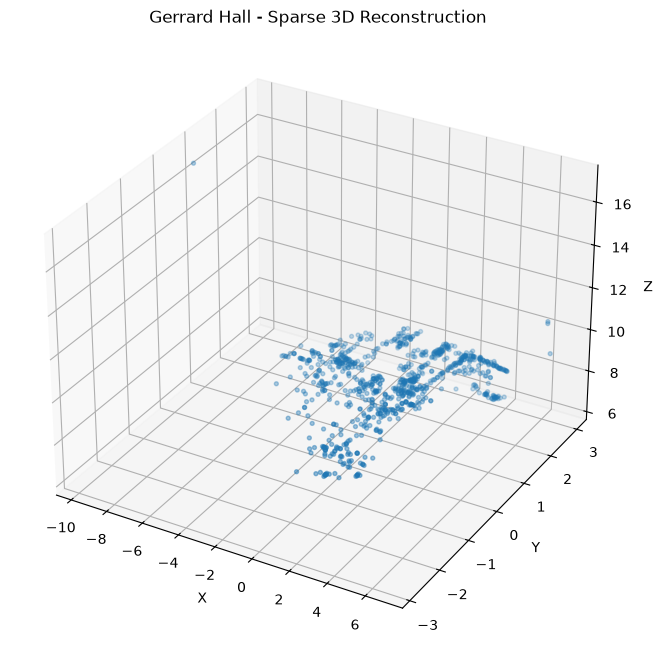

In [76]:
# 3D Visualization
# ============================================
# Step 12: Visualize sparse 3D reconstruction
# ============================================

import matplotlib.pyplot as plt

# Extract X, Y, Z
X = points_3d[0, :]
Y = points_3d[1, :]
Z = points_3d[2, :]

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")

# Plot reconstructed points
ax.scatter(
    X, Y, Z,
    s=8,
    alpha=0.7
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Gerrard Hall - Sparse 3D Reconstruction")

plt.show()

Camera 1 center:
[0. 0. 0.]

Camera 2 center:
[0.9989794  0.03975904 0.02143306]


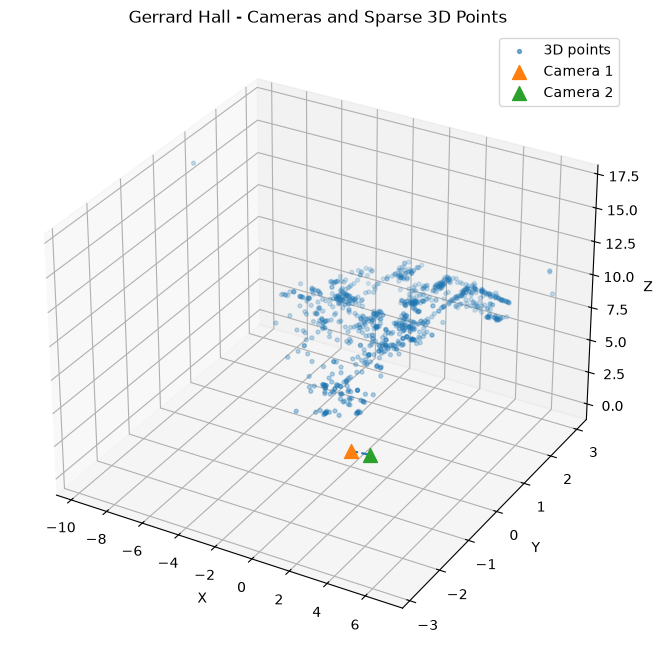

In [77]:
# ============================================
# Step 13: Add camera positions
# ============================================

# Camera 1 center
C1 = np.zeros(3)

# Camera 2 center
C2 = -R_best.T @ t_best

print("Camera 1 center:")
print(C1)

print("\nCamera 2 center:")
print(C2)

# Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# 3D points
ax.scatter(
    X, Y, Z,
    s=8,
    alpha=0.6,
    label="3D points"
)

# Camera centers
ax.scatter(
    C1[0], C1[1], C1[2],
    s=100,
    marker="^",
    label="Camera 1"
)

ax.scatter(
    C2[0], C2[1], C2[2],
    s=100,
    marker="^",
    label="Camera 2"
)

# Line between cameras
ax.plot(
    [C1[0], C2[0]],
    [C1[1], C2[1]],
    [C1[2], C2[2]],
    linestyle="--"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Gerrard Hall - Cameras and Sparse 3D Points")

ax.legend()

plt.show()

In [78]:
#Check 3D coord ranges
print("3D reconstruction statistics")
print("--------------------------------")

print("X range:", X.min(), "to", X.max())
print("Y range:", Y.min(), "to", Y.max())
print("Z range:", Z.min(), "to", Z.max())

print("\nNumber of points:", len(X))

print("\nCamera baseline:")
print("C1:", C1)
print("C2:", C2)
print("Baseline length:", np.linalg.norm(C2 - C1))

3D reconstruction statistics
--------------------------------
X range: -9.644727 to 6.7338057
Y range: -2.8174772 to 2.953919
Z range: 6.382588 to 16.922817

Number of points: 911

Camera baseline:
C1: [0. 0. 0.]
C2: [0.9989794  0.03975904 0.02143306]
Baseline length: 0.9999999999999996


In [79]:


# ============================================
# Save current two-view reconstruction
# ============================================

np.save("points_3d_two_view.npy", points_3d)

np.save("R_best.npy", R_best)
np.save("t_best.npy", t_best)
np.save("K.npy", K)

print("Saved:")
print("  points_3d_two_view.npy")
print("  R_best.npy")
print("  t_best.npy")
print("  K.npy")

Saved:
  points_3d_two_view.npy
  R_best.npy
  t_best.npy
  K.npy


In [80]:
print("Number of working images:", len(working_images))

for i, path in enumerate(working_images):
    print(i, "→", path.name)

Number of working images: 100
0 → IMG_2331.JPG
1 → IMG_2332.JPG
2 → IMG_2333.JPG
3 → IMG_2334.JPG
4 → IMG_2335.JPG
5 → IMG_2336.JPG
6 → IMG_2337.JPG
7 → IMG_2338.JPG
8 → IMG_2339.JPG
9 → IMG_2340.JPG
10 → IMG_2341.JPG
11 → IMG_2342.JPG
12 → IMG_2343.JPG
13 → IMG_2344.JPG
14 → IMG_2345.JPG
15 → IMG_2346.JPG
16 → IMG_2347.JPG
17 → IMG_2348.JPG
18 → IMG_2349.JPG
19 → IMG_2350.JPG
20 → IMG_2351.JPG
21 → IMG_2352.JPG
22 → IMG_2353.JPG
23 → IMG_2354.JPG
24 → IMG_2355.JPG
25 → IMG_2356.JPG
26 → IMG_2357.JPG
27 → IMG_2358.JPG
28 → IMG_2359.JPG
29 → IMG_2360.JPG
30 → IMG_2361.JPG
31 → IMG_2362.JPG
32 → IMG_2363.JPG
33 → IMG_2364.JPG
34 → IMG_2365.JPG
35 → IMG_2366.JPG
36 → IMG_2367.JPG
37 → IMG_2368.JPG
38 → IMG_2369.JPG
39 → IMG_2370.JPG
40 → IMG_2371.JPG
41 → IMG_2372.JPG
42 → IMG_2373.JPG
43 → IMG_2374.JPG
44 → IMG_2375.JPG
45 → IMG_2376.JPG
46 → IMG_2377.JPG
47 → IMG_2378.JPG
48 → IMG_2379.JPG
49 → IMG_2380.JPG
50 → IMG_2381.JPG
51 → IMG_2382.JPG
52 → IMG_2383.JPG
53 → IMG_2384.JPG
54 → IMG

In [81]:
# Image 3 and incremental SfM

# ============================================
# Step 15.1: Load Image 3
# ============================================

image3_path = working_images[2]

img3 = cv2.imread(str(image3_path))

print("Image 3:", image3_path.name)
print("Shape:", img3.shape)

Image 3: IMG_2333.JPG
Shape: (936, 1404, 3)


In [82]:
sift = cv2.SIFT_create()
# ============================================
# Step 15.2: SIFT features for Image 3
# ============================================

gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

kp3, des3 = sift.detectAndCompute(gray3, None)

print("Image 3 keypoints:", len(kp3))
print("Descriptor shape:", des3.shape)

Image 3 keypoints: 11138
Descriptor shape: (11138, 128)


In [85]:
# ============================================
# Step 15.1: Load Image 3
# ============================================

image3_path = working_images[2]

img3 = cv2.imread(str(image3_path))

print("Image 3:", image3_path.name)
print("Shape:", img3.shape)

Image 3: IMG_2333.JPG
Shape: (936, 1404, 3)


In [86]:
# ============================================
# Step 15.2: Extract SIFT features
# ============================================

gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp3, des3 = sift.detectAndCompute(gray3, None)

print("Image 3 keypoints:", len(kp3))
print("Descriptor shape:", des3.shape)

Image 3 keypoints: 11138
Descriptor shape: (11138, 128)


In [87]:
print("des1:", type(des1), des1.shape)
print("des2:", type(des2), des2.shape)
print("des3:", type(des3), des3.shape)

des1: <class 'numpy.ndarray'> (9292, 128)
des2: <class 'numpy.ndarray'> (9839, 128)
des3: <class 'numpy.ndarray'> (11138, 128)


In [89]:
# ============================================
# Recreate SIFT features for Image 2
# ============================================

image2_path = working_images[1]

img2 = cv2.imread(str(image2_path))

gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp2, des2_new = sift.detectAndCompute(gray2, None)

print("Image 2:", image2_path.name)
print("Image 2 keypoints:", len(kp2))
print("New descriptor shape:", des2_new.shape)
print("Existing des2 shape:", des2.shape)

Image 2: IMG_2332.JPG
Image 2 keypoints: 9839
New descriptor shape: (9839, 128)
Existing des2 shape: (9839, 128)


In [90]:
# Use the freshly recreated Image 2 SIFT data
des2 = des2_new

print("kp2:", len(kp2))
print("des2:", des2.shape)

kp2: 9839
des2: (9839, 128)


In [92]:
# ============================================
# Recreate SIFT features for Images 1 & 2
# ============================================

sift = cv2.SIFT_create()

# ---------- Image 1 ----------
image1_path = working_images[0]

img1 = cv2.imread(str(image1_path))
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

kp1, des1 = sift.detectAndCompute(gray1, None)

# ---------- Image 2 ----------
image2_path = working_images[1]

img2 = cv2.imread(str(image2_path))
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

kp2, des2 = sift.detectAndCompute(gray2, None)

# ---------- Image 3 ----------
image3_path = working_images[2]

img3 = cv2.imread(str(image3_path))
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

kp3, des3 = sift.detectAndCompute(gray3, None)


# ---------- Check ----------
print("Image 1:", image1_path.name)
print("  Keypoints:", len(kp1))
print("  Descriptors:", des1.shape)

print("\nImage 2:", image2_path.name)
print("  Keypoints:", len(kp2))
print("  Descriptors:", des2.shape)

print("\nImage 3:", image3_path.name)
print("  Keypoints:", len(kp3))
print("  Descriptors:", des3.shape)

Image 1: IMG_2331.JPG
  Keypoints: 9292
  Descriptors: (9292, 128)

Image 2: IMG_2332.JPG
  Keypoints: 9839
  Descriptors: (9839, 128)

Image 3: IMG_2333.JPG
  Keypoints: 11138
  Descriptors: (11138, 128)


GERRARD HALL — ADDING IMAGE 3

Image 2 -> Image 3
Total matches: 9839
Good matches: 1037

Existing 3D points: 911
Mapped Image-2 points: 911
Maximum mapping error: 0.0
Mean mapping error: 0.0

3D -> Image-3 correspondences: 410

PnP success: True

Camera 3 Rotation R3:
[[ 0.99344705 -0.00127909  0.11428613]
 [ 0.00530349  0.99937617 -0.03491629]
 [-0.11417017  0.03529361  0.99283409]]

Camera 3 Translation t3:
[-1.93040105  0.02581426  0.21617918]

det(R3): 1.0

Camera 3 center:
[ 1.94229554 -0.03589705  0.00688933]

PnP validation
----------------------------
PnP inliers: 406 / 410
Mean reprojection error: 0.8821241 pixels
Median reprojection error: 0.85259163 pixels
Maximum reprojection error: 2.1712582 pixels

Camera centers
----------------------------
C1: [0. 0. 0.]
C2: [0.9989794  0.03975904 0.02143306]
C3: [ 1.94229554 -0.03589705  0.00688933]


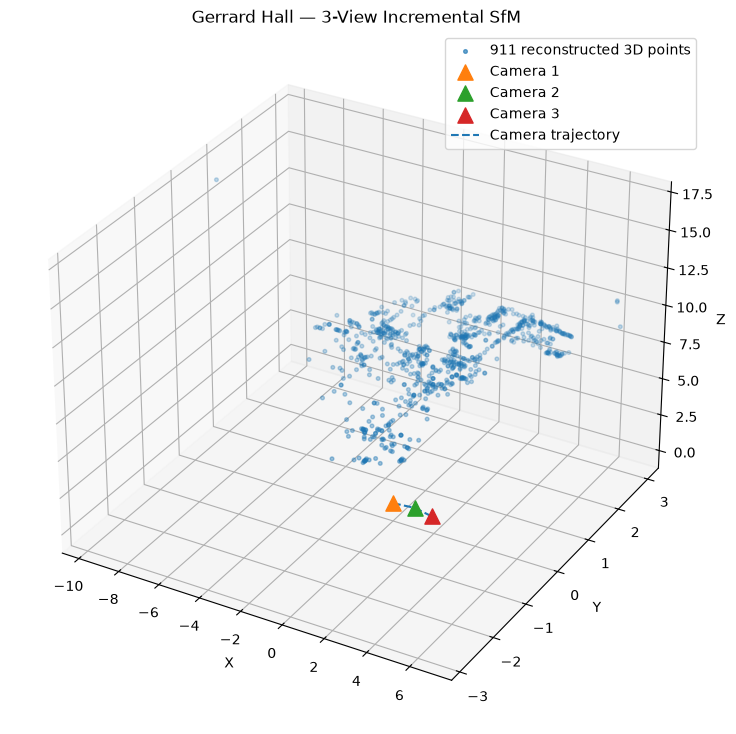


Saved Image-3 camera pose.
IMAGE 3 REGISTRATION COMPLETE


In [93]:
# ============================================================
# GERRARD HALL — IMAGE 3 REGISTRATION
# Incremental SfM using PnP + RANSAC
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("GERRARD HALL — ADDING IMAGE 3")
print("=" * 60)

# ------------------------------------------------------------
# 1. Match Image 2 -> Image 3
# ------------------------------------------------------------

bf = cv2.BFMatcher(cv2.NORM_L2)

matches_23_knn = bf.knnMatch(
    des2,
    des3,
    k=2
)

good_matches_23 = []

for m, n in matches_23_knn:
    if m.distance < 0.75 * n.distance:
        good_matches_23.append(m)

print("\nImage 2 -> Image 3")
print("Total matches:", len(matches_23_knn))
print("Good matches:", len(good_matches_23))


# ------------------------------------------------------------
# 2. Map existing 911 3D points to Image-2 keypoints
# ------------------------------------------------------------

pts2_array = np.asarray(pts2_inliers)

kp2_coords = np.array(
    [kp.pt for kp in kp2],
    dtype=np.float32
)

kp2_indices = []

for p in pts2_array:

    distances = np.linalg.norm(
        kp2_coords - p,
        axis=1
    )

    kp2_indices.append(
        np.argmin(distances)
    )

kp2_indices = np.asarray(kp2_indices)

mapping_errors = np.linalg.norm(
    kp2_coords[kp2_indices] - pts2_array,
    axis=1
)

print("\nExisting 3D points:", len(points_3d.T))
print("Mapped Image-2 points:", len(kp2_indices))
print("Maximum mapping error:",
      mapping_errors.max())
print("Mean mapping error:",
      mapping_errors.mean())


# ------------------------------------------------------------
# 3. Image-2 keypoint -> 3D landmark dictionary
# ------------------------------------------------------------

kp2_to_3d = {
    int(kp_idx): i
    for i, kp_idx in enumerate(kp2_indices)
}


# ------------------------------------------------------------
# 4. Build 3D -> Image-3 correspondences
# ------------------------------------------------------------

object_points = []
image3_points = []

used_3d = set()

for match in good_matches_23:

    idx2 = match.queryIdx
    idx3 = match.trainIdx

    if idx2 in kp2_to_3d:

        idx3d = kp2_to_3d[idx2]

        if idx3d not in used_3d:

            used_3d.add(idx3d)

            object_points.append(
                points_3d[:, idx3d]
            )

            image3_points.append(
                kp3[idx3].pt
            )

object_points = np.asarray(
    object_points,
    dtype=np.float32
)

image3_points = np.asarray(
    image3_points,
    dtype=np.float32
)

print("\n3D -> Image-3 correspondences:",
      len(object_points))


# ------------------------------------------------------------
# 5. PnP + RANSAC
# ------------------------------------------------------------

if len(object_points) < 6:

    raise RuntimeError(
        "Not enough 3D-2D correspondences for PnP."
    )

dist_coeffs = np.zeros(
    (5, 1),
    dtype=np.float64
)

success, rvec3, tvec3, inliers_pnp = cv2.solvePnPRansac(

    object_points,
    image3_points,

    K,
    dist_coeffs,

    reprojectionError=3.0,
    confidence=0.999,
    iterationsCount=2000,

    flags=cv2.SOLVEPNP_ITERATIVE
)

print("\nPnP success:", success)

if not success:

    raise RuntimeError(
        "PnP failed — Image 3 could not be registered."
    )


# ------------------------------------------------------------
# 6. Camera 3 pose
# ------------------------------------------------------------

R3, _ = cv2.Rodrigues(rvec3)

t3 = tvec3.reshape(3)

print("\nCamera 3 Rotation R3:")
print(R3)

print("\nCamera 3 Translation t3:")
print(t3)

print("\ndet(R3):",
      np.linalg.det(R3))


# ------------------------------------------------------------
# 7. Camera 3 center
# ------------------------------------------------------------

C3 = -R3.T @ t3

print("\nCamera 3 center:")
print(C3)


# ------------------------------------------------------------
# 8. Reprojection error
# ------------------------------------------------------------

inlier_idx = inliers_pnp.ravel()

obj_in = object_points[inlier_idx]

img3_in = image3_points[inlier_idx]

projected, _ = cv2.projectPoints(
    obj_in,
    rvec3,
    tvec3,
    K,
    dist_coeffs
)

projected = projected.reshape(-1, 2)

errors = np.linalg.norm(
    projected - img3_in,
    axis=1
)

print("\nPnP validation")
print("----------------------------")

print("PnP inliers:",
      len(inliers_pnp),
      "/",
      len(object_points))

print("Mean reprojection error:",
      errors.mean(),
      "pixels")

print("Median reprojection error:",
      np.median(errors),
      "pixels")

print("Maximum reprojection error:",
      errors.max(),
      "pixels")


# ------------------------------------------------------------
# 9. Camera centers
# ------------------------------------------------------------

C1 = np.zeros(3)

C2 = -R_best.T @ t_best

print("\nCamera centers")
print("----------------------------")

print("C1:", C1)
print("C2:", C2)
print("C3:", C3)


# ------------------------------------------------------------
# 10. Visualize 3-camera sparse reconstruction
# ------------------------------------------------------------

X = points_3d[0]
Y = points_3d[1]
Z = points_3d[2]

fig = plt.figure(figsize=(11, 9))

ax = fig.add_subplot(
    111,
    projection="3d"
)

# Existing 911 points
ax.scatter(
    X,
    Y,
    Z,
    s=7,
    alpha=0.65,
    label="911 reconstructed 3D points"
)

# Camera 1
ax.scatter(
    C1[0],
    C1[1],
    C1[2],
    s=120,
    marker="^",
    label="Camera 1"
)

# Camera 2
ax.scatter(
    C2[0],
    C2[1],
    C2[2],
    s=120,
    marker="^",
    label="Camera 2"
)

# Camera 3
ax.scatter(
    C3[0],
    C3[1],
    C3[2],
    s=120,
    marker="^",
    label="Camera 3"
)

# Camera trajectory
camera_centers = np.vstack(
    (C1, C2, C3)
)

ax.plot(
    camera_centers[:, 0],
    camera_centers[:, 1],
    camera_centers[:, 2],
    linestyle="--",
    label="Camera trajectory"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title(
    "Gerrard Hall — 3-View Incremental SfM"
)

ax.legend()

plt.show()


# ------------------------------------------------------------
# 11. Save Image-3 pose
# ------------------------------------------------------------

np.save(
    "gerrard_hall_R3.npy",
    R3
)

np.save(
    "gerrard_hall_t3.npy",
    t3
)

np.save(
    "gerrard_hall_C3.npy",
    C3
)

print("\nSaved Image-3 camera pose.")
print("=" * 60)
print("IMAGE 3 REGISTRATION COMPLETE")
print("=" * 60)

In [94]:
print("Number of working images:", len(working_images))

for i, p in enumerate(working_images):
    print(i, p.name)

Number of working images: 100
0 IMG_2331.JPG
1 IMG_2332.JPG
2 IMG_2333.JPG
3 IMG_2334.JPG
4 IMG_2335.JPG
5 IMG_2336.JPG
6 IMG_2337.JPG
7 IMG_2338.JPG
8 IMG_2339.JPG
9 IMG_2340.JPG
10 IMG_2341.JPG
11 IMG_2342.JPG
12 IMG_2343.JPG
13 IMG_2344.JPG
14 IMG_2345.JPG
15 IMG_2346.JPG
16 IMG_2347.JPG
17 IMG_2348.JPG
18 IMG_2349.JPG
19 IMG_2350.JPG
20 IMG_2351.JPG
21 IMG_2352.JPG
22 IMG_2353.JPG
23 IMG_2354.JPG
24 IMG_2355.JPG
25 IMG_2356.JPG
26 IMG_2357.JPG
27 IMG_2358.JPG
28 IMG_2359.JPG
29 IMG_2360.JPG
30 IMG_2361.JPG
31 IMG_2362.JPG
32 IMG_2363.JPG
33 IMG_2364.JPG
34 IMG_2365.JPG
35 IMG_2366.JPG
36 IMG_2367.JPG
37 IMG_2368.JPG
38 IMG_2369.JPG
39 IMG_2370.JPG
40 IMG_2371.JPG
41 IMG_2372.JPG
42 IMG_2373.JPG
43 IMG_2374.JPG
44 IMG_2375.JPG
45 IMG_2376.JPG
46 IMG_2377.JPG
47 IMG_2378.JPG
48 IMG_2379.JPG
49 IMG_2380.JPG
50 IMG_2381.JPG
51 IMG_2382.JPG
52 IMG_2383.JPG
53 IMG_2384.JPG
54 IMG_2385.JPG
55 IMG_2386.JPG
56 IMG_2387.JPG
57 IMG_2388.JPG
58 IMG_2389.JPG
59 IMG_2390.JPG
60 IMG_2391.JPG
61 I

In [95]:
# Register image 4
# ============================================================
# STEP 21 — REGISTER IMAGE 4
# Incremental SfM: Image 3 -> Image 4
# ============================================================

import cv2
import numpy as np

print("=" * 60)
print("REGISTERING IMAGE 4")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load Image 4
# ------------------------------------------------------------

image4_path = working_images[3]

img4 = cv2.imread(str(image4_path))
gray4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp4, des4 = sift.detectAndCompute(
    gray4,
    None
)

print("\nImage 4:", image4_path.name)
print("Keypoints:", len(kp4))
print("Descriptors:", des4.shape)


# ------------------------------------------------------------
# 2. Match Image 3 -> Image 4
# ------------------------------------------------------------

bf = cv2.BFMatcher(cv2.NORM_L2)

matches_34_knn = bf.knnMatch(
    des3,
    des4,
    k=2
)

good_matches_34 = []

for m, n in matches_34_knn:

    if m.distance < 0.75 * n.distance:
        good_matches_34.append(m)

print("\nImage 3 -> Image 4")
print("Total matches:", len(matches_34_knn))
print("Good matches:", len(good_matches_34))


# ------------------------------------------------------------
# 3. Build Image-3 keypoint -> 3D landmark map
# ------------------------------------------------------------
#
# object_points and image3_points came from our successful
# Image-3 PnP step.
#
# We recover the corresponding Image-3 SIFT keypoint indices.
# ------------------------------------------------------------

image3_points_array = np.asarray(
    image3_points
)

kp3_coords = np.array(
    [kp.pt for kp in kp3],
    dtype=np.float32
)

kp3_indices = []

for p in image3_points_array:

    distances = np.linalg.norm(
        kp3_coords - p,
        axis=1
    )

    kp3_indices.append(
        np.argmin(distances)
    )

kp3_indices = np.asarray(kp3_indices)

print("\n3D landmarks available from Image 3:",
      len(object_points))


# ------------------------------------------------------------
# 4. Map Image-3 keypoint -> 3D point
# ------------------------------------------------------------

kp3_to_3d = {}

for i, kp_idx in enumerate(kp3_indices):

    kp3_to_3d[int(kp_idx)] = i


# ------------------------------------------------------------
# 5. Build 3D -> Image-4 correspondences
# ------------------------------------------------------------

object_points_4 = []
image4_points = []

used_landmarks = set()

for match in good_matches_34:

    idx3 = match.queryIdx
    idx4 = match.trainIdx

    if idx3 in kp3_to_3d:

        landmark_idx = kp3_to_3d[idx3]

        if landmark_idx not in used_landmarks:

            used_landmarks.add(
                landmark_idx
            )

            object_points_4.append(
                object_points[landmark_idx]
            )

            image4_points.append(
                kp4[idx4].pt
            )


object_points_4 = np.asarray(
    object_points_4,
    dtype=np.float32
)

image4_points = np.asarray(
    image4_points,
    dtype=np.float32
)

print("\n3D -> Image-4 correspondences:",
      len(object_points_4))


# ------------------------------------------------------------
# 6. PnP + RANSAC
# ------------------------------------------------------------

if len(object_points_4) < 6:

    raise RuntimeError(
        "Not enough 3D-2D correspondences for PnP."
    )

dist_coeffs = np.zeros(
    (5, 1),
    dtype=np.float64
)

success4, rvec4, tvec4, inliers4 = cv2.solvePnPRansac(

    object_points_4,
    image4_points,

    K,
    dist_coeffs,

    reprojectionError=3.0,
    confidence=0.999,
    iterationsCount=2000,

    flags=cv2.SOLVEPNP_ITERATIVE
)

print("\nPnP success:", success4)

if not success4:

    raise RuntimeError(
        "Image 4 PnP failed."
    )


# ------------------------------------------------------------
# 7. Camera 4 rotation and translation
# ------------------------------------------------------------

R4, _ = cv2.Rodrigues(rvec4)

t4 = tvec4.reshape(3)

print("\nCamera 4 Rotation R4:")
print(R4)

print("\nCamera 4 Translation t4:")
print(t4)

print("\ndet(R4):",
      np.linalg.det(R4))


# ------------------------------------------------------------
# 8. Camera 4 center
# ------------------------------------------------------------

C4 = -R4.T @ t4

print("\nCamera 4 center:")
print(C4)


# ------------------------------------------------------------
# 9. Reprojection error
# ------------------------------------------------------------

inlier_indices4 = inliers4.ravel()

obj4_in = object_points_4[
    inlier_indices4
]

img4_in = image4_points[
    inlier_indices4
]

projected4, _ = cv2.projectPoints(
    obj4_in,
    rvec4,
    tvec4,
    K,
    dist_coeffs
)

projected4 = projected4.reshape(-1, 2)

errors4 = np.linalg.norm(
    projected4 - img4_in,
    axis=1
)

print("\nIMAGE 4 PnP VALIDATION")
print("----------------------------")

print(
    "PnP inliers:",
    len(inliers4),
    "/",
    len(object_points_4)
)

print(
    "Inlier ratio:",
    len(inliers4) / len(object_points_4)
)

print(
    "Mean reprojection error:",
    errors4.mean(),
    "pixels"
)

print(
    "Median reprojection error:",
    np.median(errors4),
    "pixels"
)

print(
    "Maximum reprojection error:",
    errors4.max(),
    "pixels"
)


# ------------------------------------------------------------
# 10. Camera trajectory
# ------------------------------------------------------------

C1 = np.zeros(3)

C2 = -R_best.T @ t_best

C3 = -R3.T @ t3

print("\nCAMERA CENTERS")
print("----------------------------")

print("C1:", C1)
print("C2:", C2)
print("C3:", C3)
print("C4:", C4)


# ------------------------------------------------------------
# 11. Save Camera 4
# ------------------------------------------------------------

np.save(
    "gerrard_hall_R4.npy",
    R4
)

np.save(
    "gerrard_hall_t4.npy",
    t4
)

np.save(
    "gerrard_hall_C4.npy",
    C4
)

print("\nImage 4 camera pose saved.")

print("=" * 60)
print("IMAGE 4 REGISTRATION COMPLETE")
print("=" * 60)

REGISTERING IMAGE 4

Image 4: IMG_2334.JPG
Keypoints: 12155
Descriptors: (12155, 128)

Image 3 -> Image 4
Total matches: 11138
Good matches: 960

3D landmarks available from Image 3: 410

3D -> Image-4 correspondences: 213

PnP success: True

Camera 4 Rotation R4:
[[ 0.96331551  0.04578438  0.26443718]
 [-0.03175916  0.99786467 -0.05707412]
 [-0.26648562  0.04658208  0.96271259]]

Camera 4 Translation t4:
[-2.54692546  0.17812292  0.72775145]

det(R4): 1.0

Camera 4 center:
[ 2.65308512 -0.09503335 -0.0169475 ]

IMAGE 4 PnP VALIDATION
----------------------------
PnP inliers: 176 / 213
Inlier ratio: 0.8262910798122066
Mean reprojection error: 1.405552 pixels
Median reprojection error: 1.3538635 pixels
Maximum reprojection error: 2.9335313 pixels

CAMERA CENTERS
----------------------------
C1: [0. 0. 0.]
C2: [0.9989794  0.03975904 0.02143306]
C3: [ 1.94229554 -0.03589705  0.00688933]
C4: [ 2.65308512 -0.09503335 -0.0169475 ]

Image 4 camera pose saved.
IMAGE 4 REGISTRATION COMPLETE


In [96]:
# Multi-view reconstrution state
# ============================================================
# STEP 22 — INITIALIZE MULTI-VIEW SfM STATE
# ============================================================

import numpy as np

print("=" * 60)
print("INITIALIZING MULTI-VIEW SfM")
print("=" * 60)

# ------------------------------------------------------------
# 1. Existing 3D point cloud
# ------------------------------------------------------------

points_3d_map = points_3d.copy()

print("\nInitial 3D landmarks:",
      points_3d_map.shape[1])


# ------------------------------------------------------------
# 2. Camera poses
# ------------------------------------------------------------

camera_poses = {}

# Camera 1
camera_poses[0] = {
    "R": np.eye(3),
    "t": np.zeros(3),
    "C": np.zeros(3)
}

# Camera 2
C2 = -R_best.T @ t_best

camera_poses[1] = {
    "R": R_best.copy(),
    "t": t_best.copy(),
    "C": C2.copy()
}

# Camera 3
camera_poses[2] = {
    "R": R3.copy(),
    "t": t3.copy(),
    "C": C3.copy()
}

# Camera 4
camera_poses[3] = {
    "R": R4.copy(),
    "t": t4.copy(),
    "C": C4.copy()
}


# ------------------------------------------------------------
# 3. Display camera trajectory
# ------------------------------------------------------------

print("\nRegistered cameras:")

for idx in sorted(camera_poses):

    C = camera_poses[idx]["C"]

    print(
        f"Camera {idx+1}: "
        f"({C[0]:.4f}, "
        f"{C[1]:.4f}, "
        f"{C[2]:.4f})"
    )


# ------------------------------------------------------------
# 4. Reconstruction statistics
# ------------------------------------------------------------

print("\nCurrent reconstruction")
print("----------------------------")

print("Images registered:", len(camera_poses))

print("3D landmarks:",
      points_3d_map.shape[1])

print("Next image index:",
      4)

print("Next image:",
      working_images[4].name)

print("\nState initialization complete.")

INITIALIZING MULTI-VIEW SfM

Initial 3D landmarks: 911

Registered cameras:
Camera 1: (0.0000, 0.0000, 0.0000)
Camera 2: (0.9990, 0.0398, 0.0214)
Camera 3: (1.9423, -0.0359, 0.0069)
Camera 4: (2.6531, -0.0950, -0.0169)

Current reconstruction
----------------------------
Images registered: 4
3D landmarks: 911
Next image index: 4
Next image: IMG_2335.JPG

State initialization complete.


In [98]:
# ============================================================
# IMAGE 5 — PnP DIAGNOSTIC
# ============================================================

print("=" * 60)
print("DIAGNOSING IMAGE 5 PnP")
print("=" * 60)

# Image 4 -> Image 5 matching
bf = cv2.BFMatcher(cv2.NORM_L2)

matches_45_knn = bf.knnMatch(
    des4,
    des5,
    k=2
)

good_matches_45 = []

for m, n in matches_45_knn:
    if m.distance < 0.75 * n.distance:
        good_matches_45.append(m)

print("\nImage 4 -> Image 5")
print("Total matches:", len(matches_45_knn))
print("Good matches:", len(good_matches_45))


# ------------------------------------------------------------
# Existing Image-4 3D correspondences
# ------------------------------------------------------------

print("\nImage-4 PnP correspondences:")
print("3D points:", len(object_points))
print("2D Image-4 points:", len(image4_points))


# ------------------------------------------------------------
# Recover Image-4 keypoint indices
# ------------------------------------------------------------

kp4_coords = np.array(
    [kp.pt for kp in kp4],
    dtype=np.float32
)

image4_points_array = np.asarray(
    image4_points,
    dtype=np.float32
)

kp4_indices = []

for p in image4_points_array:

    distances = np.linalg.norm(
        kp4_coords - p,
        axis=1
    )

    kp4_indices.append(
        np.argmin(distances)
    )

kp4_indices = np.asarray(kp4_indices)


# ------------------------------------------------------------
# Check mapping accuracy
# ------------------------------------------------------------

mapping_errors = np.linalg.norm(
    kp4_coords[kp4_indices]
    - image4_points_array,
    axis=1
)

print("\nImage-4 keypoint mapping:")
print("Mean mapping error:",
      mapping_errors.mean())

print("Maximum mapping error:",
      mapping_errors.max())


# ------------------------------------------------------------
# Image-4 keypoint -> 3D landmark
# ------------------------------------------------------------

kp4_to_3d = {
    int(kp_idx): i
    for i, kp_idx in enumerate(kp4_indices)
}


# ------------------------------------------------------------
# Count potential 3D -> Image-5 correspondences
# ------------------------------------------------------------

object_points_5_test = []
image5_points_test = []

for match in good_matches_45:

    idx4 = match.queryIdx
    idx5 = match.trainIdx

    if idx4 in kp4_to_3d:

        landmark_idx = kp4_to_3d[idx4]

        object_points_5_test.append(
            object_points[landmark_idx]
        )

        image5_points_test.append(
            kp5[idx5].pt
        )


print("\nPotential 3D -> Image-5 correspondences:",
      len(object_points_5_test))

print("=" * 60)

DIAGNOSING IMAGE 5 PnP

Image 4 -> Image 5
Total matches: 12155
Good matches: 1012

Image-4 PnP correspondences:
3D points: 410
2D Image-4 points: 213

Image-4 keypoint mapping:
Mean mapping error: 0.0
Maximum mapping error: 0.0

Potential 3D -> Image-5 correspondences: 135


In [99]:
# ============================================================
# STEP 23 — CORRECTED IMAGE 5 REGISTRATION
# ============================================================

print("=" * 60)
print("REGISTERING IMAGE 5 — CORRECTED")
print("=" * 60)


# ------------------------------------------------------------
# 1. Image 4 -> Image 5 matching
# ------------------------------------------------------------

bf = cv2.BFMatcher(cv2.NORM_L2)

matches_45_knn = bf.knnMatch(
    des4,
    des5,
    k=2
)

good_matches_45 = []

for m, n in matches_45_knn:

    if m.distance < 0.75 * n.distance:
        good_matches_45.append(m)

print("\nImage 4 -> Image 5")
print("Good matches:", len(good_matches_45))


# ------------------------------------------------------------
# 2. Map Image-4 keypoints to the CORRECT 3D points
# ------------------------------------------------------------
#
# IMPORTANT:
#
# object_points_4 contains the 3D points associated with
# image4_points.
#
# Therefore kp4_to_3d must point into object_points_4,
# NOT object_points.
# ------------------------------------------------------------

kp4_coords = np.array(
    [kp.pt for kp in kp4],
    dtype=np.float32
)

image4_points_array = np.asarray(
    image4_points,
    dtype=np.float32
)

kp4_indices = []

for p in image4_points_array:

    distances = np.linalg.norm(
        kp4_coords - p,
        axis=1
    )

    kp4_indices.append(
        np.argmin(distances)
    )

kp4_indices = np.asarray(kp4_indices)

kp4_to_3d = {
    int(kp_idx): i
    for i, kp_idx in enumerate(kp4_indices)
}

print("\nImage-4 landmarks available:",
      len(object_points_4))


# ------------------------------------------------------------
# 3. Build correct 3D -> Image-5 correspondences
# ------------------------------------------------------------

object_points_5 = []
image5_points_corresponding = []

used_landmarks = set()

for match in good_matches_45:

    idx4 = match.queryIdx
    idx5 = match.trainIdx

    if idx4 in kp4_to_3d:

        landmark_idx = kp4_to_3d[idx4]

        if landmark_idx not in used_landmarks:

            used_landmarks.add(landmark_idx)

            # CORRECT ARRAY:
            object_points_5.append(
                object_points_4[landmark_idx]
            )

            image5_points_corresponding.append(
                kp5[idx5].pt
            )


object_points_5 = np.asarray(
    object_points_5,
    dtype=np.float32
)

image5_points_corresponding = np.asarray(
    image5_points_corresponding,
    dtype=np.float32
)

print("\n3D -> Image-5 correspondences:",
      len(object_points_5))


# ------------------------------------------------------------
# 4. PnP + RANSAC
# ------------------------------------------------------------

if len(object_points_5) < 6:

    raise RuntimeError(
        "Not enough 3D-2D correspondences."
    )

dist_coeffs = np.zeros(
    (5, 1),
    dtype=np.float64
)

success5, rvec5, tvec5, inliers5 = cv2.solvePnPRansac(

    object_points_5,
    image5_points_corresponding,

    K,
    dist_coeffs,

    reprojectionError=3.0,
    confidence=0.999,
    iterationsCount=2000,

    flags=cv2.SOLVEPNP_ITERATIVE
)

print("\nPnP success:", success5)

if not success5:

    raise RuntimeError(
        "Image 5 PnP failed even after correcting "
        "the 3D landmark mapping."
    )


# ------------------------------------------------------------
# 5. Recover Camera 5 pose
# ------------------------------------------------------------

R5, _ = cv2.Rodrigues(rvec5)

t5 = tvec5.reshape(3)

C5 = -R5.T @ t5

print("\nCamera 5 Rotation R5:")
print(R5)

print("\nCamera 5 Translation t5:")
print(t5)

print("\ndet(R5):",
      np.linalg.det(R5))

print("\nCamera 5 center:")
print(C5)


# ------------------------------------------------------------
# 6. Reprojection error
# ------------------------------------------------------------

inlier_indices5 = inliers5.ravel()

obj5_in = object_points_5[
    inlier_indices5
]

img5_in = image5_points_corresponding[
    inlier_indices5
]

projected5, _ = cv2.projectPoints(
    obj5_in,
    rvec5,
    tvec5,
    K,
    dist_coeffs
)

projected5 = projected5.reshape(-1, 2)

errors5 = np.linalg.norm(
    projected5 - img5_in,
    axis=1
)

print("\nIMAGE 5 PnP VALIDATION")
print("----------------------------")

print(
    "PnP inliers:",
    len(inliers5),
    "/",
    len(object_points_5)
)

print(
    "Inlier ratio:",
    len(inliers5) / len(object_points_5)
)

print(
    "Mean reprojection error:",
    errors5.mean(),
    "pixels"
)

print(
    "Median reprojection error:",
    np.median(errors5),
    "pixels"
)

print(
    "Maximum reprojection error:",
    errors5.max(),
    "pixels"
)


# ------------------------------------------------------------
# 7. Add Camera 5 to reconstruction
# ------------------------------------------------------------

camera_poses[4] = {
    "R": R5.copy(),
    "t": t5.copy(),
    "C": C5.copy()
}


# ------------------------------------------------------------
# 8. Camera 5 projection matrix
# ------------------------------------------------------------

P5 = K @ np.hstack(
    (
        R5,
        t5.reshape(3, 1)
    )
)


# ------------------------------------------------------------
# 9. Display camera trajectory
# ------------------------------------------------------------

print("\nCAMERA CENTERS")
print("----------------------------")

for idx in sorted(camera_poses):

    C = camera_poses[idx]["C"]

    print(
        f"C{idx+1}: "
        f"[{C[0]:.6f}, "
        f"{C[1]:.6f}, "
        f"{C[2]:.6f}]"
    )


# ------------------------------------------------------------
# 10. Save Camera 5
# ------------------------------------------------------------

np.save(
    "gerrard_hall_R5.npy",
    R5
)

np.save(
    "gerrard_hall_t5.npy",
    t5
)

np.save(
    "gerrard_hall_C5.npy",
    C5
)

print("\nCamera 5 saved.")

print("=" * 60)
print("IMAGE 5 REGISTRATION COMPLETE")
print("=" * 60)

REGISTERING IMAGE 5 — CORRECTED

Image 4 -> Image 5
Good matches: 1012

Image-4 landmarks available: 213

3D -> Image-5 correspondences: 135

PnP success: True

Camera 5 Rotation R5:
[[ 0.9448577   0.04414927  0.32449156]
 [-0.0360095   0.99886897 -0.03105005]
 [-0.32549539  0.0176531   0.94537882]]

Camera 5 Translation t5:
[-3.25088465  0.14338706  1.07716657]

det(R5): 1.0

Camera 5 center:
[ 3.42739944 -0.01871603  0.04100634]

IMAGE 5 PnP VALIDATION
----------------------------
PnP inliers: 114 / 135
Inlier ratio: 0.8444444444444444
Mean reprojection error: 1.3946049 pixels
Median reprojection error: 1.3517883 pixels
Maximum reprojection error: 3.9146297 pixels

CAMERA CENTERS
----------------------------
C1: [0.000000, 0.000000, 0.000000]
C2: [0.998979, 0.039759, 0.021433]
C3: [1.942296, -0.035897, 0.006889]
C4: [2.653085, -0.095033, -0.016947]
C5: [3.427399, -0.018716, 0.041006]

Camera 5 saved.
IMAGE 5 REGISTRATION COMPLETE


In [100]:
# ============================================================
# STEP 24 — TRIANGULATE NEW 3D POINTS
# Image 4 <-> Image 5
# ============================================================

print("=" * 60)
print("STEP 24 — TRIANGULATING NEW 3D POINTS")
print("=" * 60)

# ------------------------------------------------------------
# 1. Camera projection matrices
# ------------------------------------------------------------

P4 = K @ np.hstack(
    (
        R4,
        t4.reshape(3, 1)
    )
)

P5 = K @ np.hstack(
    (
        R5,
        t5.reshape(3, 1)
    )
)

print("\nProjection matrices created.")


# ------------------------------------------------------------
# 2. Identify matches that are NOT already associated
#    with existing Image-4 3D landmarks
# ------------------------------------------------------------

new_matches_45 = []

for match in good_matches_45:

    idx4 = match.queryIdx

    if idx4 not in kp4_to_3d:

        new_matches_45.append(match)


print("\nGood matches Image 4 -> Image 5:",
      len(good_matches_45))

print("Potential NEW matches:",
      len(new_matches_45))


# ------------------------------------------------------------
# 3. Extract corresponding image points
# ------------------------------------------------------------

pts4_new = np.array(
    [
        kp4[m.queryIdx].pt
        for m in new_matches_45
    ],
    dtype=np.float32
)

pts5_new = np.array(
    [
        kp5[m.trainIdx].pt
        for m in new_matches_45
    ],
    dtype=np.float32
)


# ------------------------------------------------------------
# 4. Triangulate
# ------------------------------------------------------------

if len(pts4_new) < 8:

    raise RuntimeError(
        "Not enough new matches for triangulation."
    )

points4D = cv2.triangulatePoints(
    P4,
    P5,
    pts4_new.T,
    pts5_new.T
)

points4D = (
    points4D[:3]
    /
    points4D[3]
)

print("\nRaw triangulated points:",
      points4D.shape[1])


# ------------------------------------------------------------
# 5. Positive depth test
# ------------------------------------------------------------

depth4 = (
    R4 @ points4D
    +
    t4.reshape(3, 1)
)[2]

depth5 = (
    R5 @ points4D
    +
    t5.reshape(3, 1)
)[2]

positive_depth = (
    (depth4 > 0)
    &
    (depth5 > 0)
)

print(
    "Positive-depth points:",
    np.sum(positive_depth),
    "/",
    len(positive_depth)
)


# ------------------------------------------------------------
# 6. Keep only positive-depth points
# ------------------------------------------------------------

candidate_points = points4D[
    :,
    positive_depth
]

candidate_pts4 = pts4_new[
    positive_depth
]

candidate_pts5 = pts5_new[
    positive_depth
]


# ------------------------------------------------------------
# 7. Reprojection error — Camera 4
# ------------------------------------------------------------

rvec4_check, _ = cv2.Rodrigues(R4)

projected4, _ = cv2.projectPoints(
    candidate_points.T,
    rvec4_check,
    t4,
    K,
    np.zeros((5, 1))
)

projected4 = projected4.reshape(-1, 2)

error4 = np.linalg.norm(
    projected4 - candidate_pts4,
    axis=1
)


# ------------------------------------------------------------
# 8. Reprojection error — Camera 5
# ------------------------------------------------------------

rvec5_check, _ = cv2.Rodrigues(R5)

projected5, _ = cv2.projectPoints(
    candidate_points.T,
    rvec5_check,
    t5,
    K,
    np.zeros((5, 1))
)

projected5 = projected5.reshape(-1, 2)

error5 = np.linalg.norm(
    projected5 - candidate_pts5,
    axis=1
)


# ------------------------------------------------------------
# 9. Reprojection filtering
# ------------------------------------------------------------

reprojection_threshold = 3.0

good_3d = (
    (error4 < reprojection_threshold)
    &
    (error5 < reprojection_threshold)
)

new_points = candidate_points[
    :,
    good_3d
]


# ------------------------------------------------------------
# 10. Statistics
# ------------------------------------------------------------

print("\nTRIANGULATION VALIDATION")
print("----------------------------")

print(
    "Positive-depth points:",
    candidate_points.shape[1]
)

print(
    "Good reprojection points:",
    new_points.shape[1]
)

if len(error4) > 0:

    print(
        "Mean error Camera 4:",
        error4.mean(),
        "pixels"
    )

    print(
        "Mean error Camera 5:",
        error5.mean(),
        "pixels"
    )


# ------------------------------------------------------------
# 11. Add new points to global 3D map
# ------------------------------------------------------------

old_count = points_3d_map.shape[1]

points_3d_map = np.hstack(
    (
        points_3d_map,
        new_points
    )
)

new_count = points_3d_map.shape[1]


print("\nUPDATED 3D RECONSTRUCTION")
print("----------------------------")

print("Previous points:", old_count)

print("New points:", new_points.shape[1])

print("Total points:", new_count)


# ------------------------------------------------------------
# 12. Save updated point cloud
# ------------------------------------------------------------

np.save(
    "gerrard_hall_points_3d.npy",
    points_3d_map
)

print("\n3D point cloud saved.")

print("=" * 60)
print("STEP 24 COMPLETE")
print("=" * 60)

STEP 24 — TRIANGULATING NEW 3D POINTS

Projection matrices created.

Good matches Image 4 -> Image 5: 1012
Potential NEW matches: 877

Raw triangulated points: 877
Positive-depth points: 855 / 877

TRIANGULATION VALIDATION
----------------------------
Positive-depth points: 855
Good reprojection points: 764
Mean error Camera 4: 9.582632 pixels
Mean error Camera 5: 6.4589486 pixels

UPDATED 3D RECONSTRUCTION
----------------------------
Previous points: 911
New points: 764
Total points: 1675

3D point cloud saved.
STEP 24 COMPLETE


In [101]:
print("Accepted triangulated points:", new_points.shape[1])

# Recalculate errors only for accepted points
accepted_error4 = error4[good_3d]
accepted_error5 = error5[good_3d]

print("\nAccepted-point reprojection errors")
print("----------------------------------")

print("Camera 4:")
print("  Mean:", accepted_error4.mean())
print("  Median:", np.median(accepted_error4))
print("  Maximum:", accepted_error4.max())

print("\nCamera 5:")
print("  Mean:", accepted_error5.mean())
print("  Median:", np.median(accepted_error5))
print("  Maximum:", accepted_error5.max())

Accepted triangulated points: 764

Accepted-point reprojection errors
----------------------------------
Camera 4:
  Mean: 1.0731633
  Median: 0.81418145
  Maximum: 2.9934874

Camera 5:
  Mean: 1.0464833
  Median: 0.80623925
  Maximum: 2.9253767


In [102]:
# ============================================================
# STEP 25 — BUILD IMAGE-5 → 3D LANDMARK TRACKS
# ============================================================

print("=" * 60)
print("STEP 25 — BUILDING IMAGE-5 3D TRACKS")
print("=" * 60)

# ------------------------------------------------------------
# Existing 911 landmarks
# ------------------------------------------------------------
#
# We know which Image-4 keypoints correspond to the original
# 3D points through kp4_to_3d.
#
# For Image 5, the 135 matched landmarks were stored in:
#
#   object_points_5
#   image5_points_corresponding
#
# ------------------------------------------------------------

# Map Image-5 keypoint -> original 3D landmark
image5_existing_tracks = {}

kp5_coords = np.array(
    [kp.pt for kp in kp5],
    dtype=np.float32
)

for i, pt in enumerate(image5_points_corresponding):

    distances = np.linalg.norm(
        kp5_coords - pt,
        axis=1
    )

    kp5_idx = np.argmin(distances)

    # The corresponding point in the ORIGINAL 3D map
    image5_existing_tracks[int(kp5_idx)] = i


print("\nExisting Image-5 tracks:",
      len(image5_existing_tracks))


# ------------------------------------------------------------
# New 764 triangulated landmarks
# ------------------------------------------------------------
#
# new_matches_45 contains all Image-4 ↔ Image-5 matches
# which were not already associated with a 3D landmark.
#
# good_3d tells us which triangulated points survived
# the geometric/reprojection filtering.
# ------------------------------------------------------------

new_matches_valid = [
    m
    for m, keep in zip(new_matches_45, good_3d)
    if keep
]

print("Valid new triangulation matches:",
      len(new_matches_valid))

print("New 3D landmarks:",
      new_points.shape[1])


# ------------------------------------------------------------
# Global landmark indices
# ------------------------------------------------------------

start_index = 911

image5_new_tracks = {}

for j, match in enumerate(new_matches_valid):

    kp5_idx = match.trainIdx

    global_index = start_index + j

    image5_new_tracks[int(kp5_idx)] = global_index


print(
    "New Image-5 tracks:",
    len(image5_new_tracks)
)


# ------------------------------------------------------------
# Combine tracks
# ------------------------------------------------------------

image5_to_3d = {}

image5_to_3d.update(
    image5_existing_tracks
)

image5_to_3d.update(
    image5_new_tracks
)


print("\nTOTAL IMAGE-5 TRACKS")
print("----------------------------")

print(
    "Image-5 keypoints linked to 3D:",
    len(image5_to_3d)
)

print(
    "Current global 3D landmarks:",
    points_3d_map.shape[1]
)


# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------

valid_indices = [
    idx
    for idx in image5_to_3d.values()
    if 0 <= idx < points_3d_map.shape[1]
]

print(
    "Valid landmark indices:",
    len(valid_indices)
)

print(
    "Invalid landmark indices:",
    len(image5_to_3d) - len(valid_indices)
)


# ------------------------------------------------------------
# Save track map
# ------------------------------------------------------------

np.save(
    "gerrard_hall_image5_to_3d.npy",
    image5_to_3d,
    allow_pickle=True
)

print("\nImage-5 track map saved.")

print("=" * 60)
print("STEP 25 COMPLETE")
print("=" * 60)

STEP 25 — BUILDING IMAGE-5 3D TRACKS

Existing Image-5 tracks: 135
Valid new triangulation matches: 764
New 3D landmarks: 764
New Image-5 tracks: 741

TOTAL IMAGE-5 TRACKS
----------------------------
Image-5 keypoints linked to 3D: 873
Current global 3D landmarks: 1675
Valid landmark indices: 873
Invalid landmark indices: 0

Image-5 track map saved.
STEP 25 COMPLETE


In [104]:
# ============================================================
# STEP 26 — GENERIC NEXT-IMAGE REGISTRATION
# ============================================================

def register_next_image(
    image_index,
    prev_index,
    prev_kp,
    prev_des,
    prev_to_3d
):
    """
    Register one new image against the previous image.

    image_index : index of new image in working_images
    prev_index  : index of previous registered image
    prev_kp     : SIFT keypoints of previous image
    prev_des    : SIFT descriptors of previous image
    prev_to_3d  : previous-image keypoint -> global 3D landmark
    """

    global points_3d_map

    print("=" * 60)
    print(
        f"REGISTERING IMAGE {image_index + 1}"
    )
    print("=" * 60)

    # --------------------------------------------------------
    # 1. Load new image
    # --------------------------------------------------------

    image_path = working_images[image_index]

    img = cv2.imread(str(image_path))

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    sift = cv2.SIFT_create()

    kp, des = sift.detectAndCompute(
        gray,
        None
    )

    print(
        "\nImage:",
        image_path.name
    )

    print(
        "Keypoints:",
        len(kp)
    )

    print(
        "Descriptors:",
        des.shape
    )


    # --------------------------------------------------------
    # 2. Match previous image -> new image
    # --------------------------------------------------------

    bf = cv2.BFMatcher(cv2.NORM_L2)

    knn_matches = bf.knnMatch(
        prev_des,
        des,
        k=2
    )

    good_matches = []

    for m, n in knn_matches:

        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    print(
        f"\nImage {prev_index + 1} -> "
        f"Image {image_index + 1}"
    )

    print(
        "Good matches:",
        len(good_matches)
    )


    # --------------------------------------------------------
    # 3. Build 3D -> 2D correspondences
    # --------------------------------------------------------

    object_points_new = []
    image_points_new = []

    used_landmarks = set()

    for match in good_matches:

        prev_kp_idx = match.queryIdx
        new_kp_idx = match.trainIdx

        if prev_kp_idx in prev_to_3d:

            landmark_idx = prev_to_3d[
                prev_kp_idx
            ]

            if landmark_idx in used_landmarks:
                continue

            if landmark_idx >= points_3d_map.shape[1]:
                continue

            used_landmarks.add(
                landmark_idx
            )

            object_points_new.append(
                points_3d_map[
                    :,
                    landmark_idx
                ]
            )

            image_points_new.append(
                kp[new_kp_idx].pt
            )


    object_points_new = np.asarray(
        object_points_new,
        dtype=np.float32
    )

    image_points_new = np.asarray(
        image_points_new,
        dtype=np.float32
    )

    print(
        "\n3D -> 2D correspondences:",
        len(object_points_new)
    )


    # --------------------------------------------------------
    # 4. PnP
    # --------------------------------------------------------

    if len(object_points_new) < 6:

        raise RuntimeError(
            "Not enough 3D-2D correspondences."
        )

    dist_coeffs = np.zeros(
        (5, 1),
        dtype=np.float64
    )

    success, rvec, tvec, inliers = \
        cv2.solvePnPRansac(

            object_points_new,
            image_points_new,

            K,
            dist_coeffs,

            reprojectionError=3.0,
            confidence=0.999,
            iterationsCount=2000,

            flags=cv2.SOLVEPNP_ITERATIVE
        )


    print(
        "\nPnP success:",
        success
    )

    if not success:

        raise RuntimeError(
            f"Image {image_index + 1} PnP failed."
        )


    # --------------------------------------------------------
    # 5. Camera pose
    # --------------------------------------------------------

    R, _ = cv2.Rodrigues(rvec)

    t = tvec.reshape(3)

    C = -R.T @ t

    print(
        "\nCamera center:"
    )

    print(C)

    print(
        "\ndet(R):",
        np.linalg.det(R)
    )


    # --------------------------------------------------------
    # 6. Reprojection error
    # --------------------------------------------------------

    inlier_idx = inliers.ravel()

    projected, _ = cv2.projectPoints(
        object_points_new[inlier_idx],
        rvec,
        tvec,
        K,
        dist_coeffs
    )

    projected = projected.reshape(-1, 2)

    errors = np.linalg.norm(
        projected
        - image_points_new[inlier_idx],
        axis=1
    )

    print(
        f"\nIMAGE {image_index + 1} PnP VALIDATION"
    )

    print(
        "----------------------------"
    )

    print(
        "PnP inliers:",
        len(inliers),
        "/",
        len(object_points_new)
    )

    print(
        "Inlier ratio:",
        len(inliers)
        / len(object_points_new)
    )

    print(
        "Mean reprojection error:",
        errors.mean(),
        "pixels"
    )

    print(
        "Median reprojection error:",
        np.median(errors),
        "pixels"
    )

    print(
        "Maximum reprojection error:",
        errors.max(),
        "pixels"
    )


    # --------------------------------------------------------
    # 7. Projection matrix
    # --------------------------------------------------------

    P = K @ np.hstack(
        (
            R,
            t.reshape(3, 1)
        )
    )


    # --------------------------------------------------------
    # 8. Save camera pose
    # --------------------------------------------------------

    camera_poses[image_index] = {
        "R": R.copy(),
        "t": t.copy(),
        "C": C.copy()
    }


    print(
        "\nCamera pose stored."
    )

    print(
        f"Image {image_index + 1} "
        "registration complete."
    )


    # --------------------------------------------------------
    # 9. Return everything needed for triangulation
    # --------------------------------------------------------

    return {
        "image": img,
        "kp": kp,
        "des": des,
        "good_matches": good_matches,
        "R": R,
        "t": t,
        "C": C,
        "P": P,
        "object_points": object_points_new,
        "image_points": image_points_new,
        "inliers": inliers
    }

In [105]:
# ============================================================
# STEP 26B — REGISTER IMAGE 6
# ============================================================

result6 = register_next_image(
    image_index=5,
    prev_index=4,
    prev_kp=kp5,
    prev_des=des5,
    prev_to_3d=image5_to_3d
)

kp6 = result6["kp"]
des6 = result6["des"]

R6 = result6["R"]
t6 = result6["t"]
C6 = result6["C"]
P6 = result6["P"]

good_matches_56 = result6["good_matches"]

print("\n" + "=" * 60)
print("IMAGE 6 REGISTRATION SUCCESSFUL")
print("=" * 60)

REGISTERING IMAGE 6

Image: IMG_2336.JPG
Keypoints: 11593
Descriptors: (11593, 128)

Image 5 -> Image 6
Good matches: 521

3D -> 2D correspondences: 228

PnP success: False


RuntimeError: Image 6 PnP failed.

In [108]:
# ============================================================
# PREPARE IMAGE 6 — IMG_2336.JPG
# ============================================================

image6_path = working_images[5]

img6 = cv2.imread(str(image6_path))

if img6 is None:
    raise RuntimeError(
        f"Could not read image: {image6_path}"
    )

gray6 = cv2.cvtColor(
    img6,
    cv2.COLOR_BGR2GRAY
)

sift = cv2.SIFT_create()

kp6, des6 = sift.detectAndCompute(
    gray6,
    None
)

print("=" * 60)
print("IMAGE 6 PREPARED")
print("=" * 60)

print("Image:", image6_path.name)
print("Shape:", img6.shape)
print("Keypoints:", len(kp6))
print("Descriptors:", des6.shape)

IMAGE 6 PREPARED
Image: IMG_2336.JPG
Shape: (936, 1404, 3)
Keypoints: 11593
Descriptors: (11593, 128)


In [109]:
# ============================================================
# IMAGE 6 — PnP CORRESPONDENCE DIAGNOSTIC
# ============================================================

print("=" * 60)
print("IMAGE 6 — PnP CORRESPONDENCE DIAGNOSTIC")
print("=" * 60)

# ------------------------------------------------------------
# Match Image 5 -> Image 6
# ------------------------------------------------------------

bf = cv2.BFMatcher(cv2.NORM_L2)

matches_56_knn = bf.knnMatch(
    des5,
    des6,
    k=2
)

good_matches_56 = []

for m, n in matches_56_knn:

    if m.distance < 0.75 * n.distance:
        good_matches_56.append(m)

print("\nImage 5 -> Image 6")
print("Total matches:", len(matches_56_knn))
print("Good matches:", len(good_matches_56))


# ------------------------------------------------------------
# Examine Image-5 -> 3D mapping
# ------------------------------------------------------------

print("\nImage-5 -> 3D tracks:",
      len(image5_to_3d))

valid_track_count = 0
invalid_track_count = 0

object_points_test = []
image6_points_test = []

used_landmarks = set()

for match in good_matches_56:

    kp5_idx = match.queryIdx
    kp6_idx = match.trainIdx

    if kp5_idx not in image5_to_3d:
        continue

    landmark_idx = image5_to_3d[kp5_idx]

    if not (
        0 <= landmark_idx
        < points_3d_map.shape[1]
    ):
        invalid_track_count += 1
        continue

    if landmark_idx in used_landmarks:
        continue

    used_landmarks.add(landmark_idx)

    object_points_test.append(
        points_3d_map[:, landmark_idx]
    )

    image6_points_test.append(
        kp6[kp6_idx].pt
    )

    valid_track_count += 1


object_points_test = np.asarray(
    object_points_test,
    dtype=np.float32
)

image6_points_test = np.asarray(
    image6_points_test,
    dtype=np.float32
)


print("\n3D -> Image-6 correspondence check")
print("----------------------------------")

print(
    "Valid correspondences:",
    valid_track_count
)

print(
    "Invalid landmark references:",
    invalid_track_count
)

print(
    "Unique 3D landmarks used:",
    len(used_landmarks)
)


# ------------------------------------------------------------
# Basic 3D sanity check
# ------------------------------------------------------------

if len(object_points_test) > 0:

    print(
        "\n3D coordinate range:"
    )

    print(
        "X:",
        object_points_test[:, 0].min(),
        "to",
        object_points_test[:, 0].max()
    )

    print(
        "Y:",
        object_points_test[:, 1].min(),
        "to",
        object_points_test[:, 1].max()
    )

    print(
        "Z:",
        object_points_test[:, 2].min(),
        "to",
        object_points_test[:, 2].max()
    )

print("=" * 60)

IMAGE 6 — PnP CORRESPONDENCE DIAGNOSTIC

Image 5 -> Image 6
Total matches: 11739
Good matches: 521

Image-5 -> 3D tracks: 873

3D -> Image-6 correspondence check
----------------------------------
Valid correspondences: 228
Invalid landmark references: 0
Unique 3D landmarks used: 228

3D coordinate range:
X: -16.171293 to 10.158379
Y: -6.5766196 to 4.7232537
Z: 3.5295827 to 21.099077


In [114]:
# ============================================================
# STEP 26 — ROBUST PnP FOR IMAGE 6
# ============================================================

print("=" * 60)
print("ROBUST PnP — IMAGE 6")
print("=" * 60)

# Use the correspondences from the diagnostic
obj6 = object_points_test.copy()
img6_pts = image6_points_test.copy()

print("\nInput correspondences:", len(obj6))


# ------------------------------------------------------------
# 1. Camera intrinsics
# ------------------------------------------------------------

dist_coeffs = np.zeros(
    (5, 1),
    dtype=np.float64
)


# ------------------------------------------------------------
# 2. Robust PnP RANSAC
# ------------------------------------------------------------

success6, rvec6, tvec6, inliers6 = cv2.solvePnPRansac(

    obj6,
    img6_pts,

    K,
    dist_coeffs,

    iterationsCount=5000,
    reprojectionError=4.0,
    confidence=0.9999,

    flags=cv2.SOLVEPNP_ITERATIVE
)

print("\nPnP success:", success6)

if not success6:

    raise RuntimeError(
        "Robust PnP still failed for Image 6."
    )


# ------------------------------------------------------------
# 3. Recover camera pose
# ------------------------------------------------------------

R6, _ = cv2.Rodrigues(rvec6)

t6 = tvec6.reshape(3)

C6 = -R6.T @ t6

print("\nCamera 6 Rotation:")
print(R6)

print("\nCamera 6 Translation:")
print(t6)

print("\nCamera 6 Center:")
print(C6)

print("\ndet(R6):",
      np.linalg.det(R6))


# ------------------------------------------------------------
# 4. Reprojection validation
# ------------------------------------------------------------

inlier_idx6 = inliers6.ravel()

projected6, _ = cv2.projectPoints(
    obj6[inlier_idx6],
    rvec6,
    tvec6,
    K,
    dist_coeffs
)

projected6 = projected6.reshape(-1, 2)

errors6 = np.linalg.norm(
    projected6
    - img6_pts[inlier_idx6],
    axis=1
)

print("\nIMAGE 6 PnP VALIDATION")
print("----------------------------")

print(
    "PnP inliers:",
    len(inliers6),
    "/",
    len(obj6)
)

print(
    "Inlier ratio:",
    len(inliers6) / len(obj6)
)

print(
    "Mean reprojection error:",
    errors6.mean(),
    "pixels"
)

print(
    "Median reprojection error:",
    np.median(errors6),
    "pixels"
)

print(
    "Maximum reprojection error:",
    errors6.max(),
    "pixels"
)


# ------------------------------------------------------------
# 5. Save the pose temporarily
# ------------------------------------------------------------

P6 = K @ np.hstack(
    (
        R6,
        t6.reshape(3, 1)
    )
)

print("\nImage 6 pose estimated successfully.")

print("=" * 60)

ROBUST PnP — IMAGE 6

Input correspondences: 228

PnP success: False


RuntimeError: Robust PnP still failed for Image 6.

In [111]:
# ============================================================
# STEP 26A — REBUILD IMAGE-5 → GLOBAL 3D TRACK MAP
# ============================================================

print("=" * 60)
print("REBUILDING IMAGE-5 GLOBAL 3D TRACKS")
print("=" * 60)

# ------------------------------------------------------------
# Global map before Image-5 triangulation
# ------------------------------------------------------------

initial_3d_count = 911

print("\nGlobal 3D map:")
print("  Initial points:", initial_3d_count)
print("  Current points:", points_3d_map.shape[1])


# ------------------------------------------------------------
# Create fresh Image-5 -> global 3D map
# ------------------------------------------------------------

image5_to_3d = {}


# ============================================================
# PART 1 — Existing 3D landmarks
# ============================================================

# object_points_5 contains the 135 3D points that were
# matched from Image 4 to Image 5.
#
# We must find where each of these points occurs in the
# ORIGINAL 911-point global cloud.
# ============================================================

global_initial_points = points_3d_map[:, :initial_3d_count]

existing_track_count = 0

for i, pt3d in enumerate(object_points_5):

    # Find the exact/nearest original global landmark
    distances = np.linalg.norm(
        global_initial_points.T - pt3d,
        axis=1
    )

    global_idx = np.argmin(distances)

    min_distance = distances[global_idx]

    # Because these points came directly from the original
    # reconstruction, the distance should be essentially zero.
    if min_distance < 1e-5:

        # Find corresponding Image-5 keypoint
        pt2d = image5_points_corresponding[i]

        distances_2d = np.linalg.norm(
            kp5_coords - pt2d,
            axis=1
        )

        kp5_idx = np.argmin(distances_2d)

        # Avoid duplicate Image-5 keypoints
        if int(kp5_idx) not in image5_to_3d:

            image5_to_3d[int(kp5_idx)] = int(global_idx)

            existing_track_count += 1


print("\nExisting global tracks:",
      existing_track_count)


# ============================================================
# PART 2 — Newly triangulated points
# ============================================================

# new_points contains the accepted triangulated points.
#
# They were appended to points_3d_map starting at index 911.
#
# new_matches_valid corresponds to the triangulated points,
# in the same order.
# ============================================================

new_track_count = 0

for j, match in enumerate(new_matches_valid):

    kp5_idx = int(match.trainIdx)

    global_idx = initial_3d_count + j

    # Make sure the global index exists
    if global_idx >= points_3d_map.shape[1]:
        continue

    # Only assign if this Image-5 keypoint is not already
    # associated with an existing landmark.
    if kp5_idx not in image5_to_3d:

        image5_to_3d[kp5_idx] = global_idx

        new_track_count += 1


print(
    "New triangulated tracks:",
    new_track_count
)


# ============================================================
# PART 3 — Final validation
# ============================================================

valid_indices = []

for kp_idx, landmark_idx in image5_to_3d.items():

    if (
        0 <= landmark_idx
        < points_3d_map.shape[1]
    ):
        valid_indices.append(
            landmark_idx
        )


print("\nIMAGE-5 GLOBAL TRACK SUMMARY")
print("----------------------------")

print(
    "Total Image-5 -> 3D tracks:",
    len(image5_to_3d)
)

print(
    "Valid global indices:",
    len(valid_indices)
)

print(
    "Invalid indices:",
    len(image5_to_3d)
    - len(valid_indices)
)


# ------------------------------------------------------------
# Check uniqueness
# ------------------------------------------------------------

unique_landmarks = len(
    set(valid_indices)
)

print(
    "Unique 3D landmarks:",
    unique_landmarks
)


# ------------------------------------------------------------
# Save repaired map
# ------------------------------------------------------------

np.save(
    "gerrard_hall_image5_to_3d_fixed.npy",
    image5_to_3d,
    allow_pickle=True
)

print("\nCorrected Image-5 track map saved.")

print("=" * 60)
print("IMAGE-5 TRACK REBUILD COMPLETE")
print("=" * 60)

REBUILDING IMAGE-5 GLOBAL 3D TRACKS

Global 3D map:
  Initial points: 911
  Current points: 1675

Existing global tracks: 135
New triangulated tracks: 738

IMAGE-5 GLOBAL TRACK SUMMARY
----------------------------
Total Image-5 -> 3D tracks: 873
Valid global indices: 873
Invalid indices: 0
Unique 3D landmarks: 873

Corrected Image-5 track map saved.
IMAGE-5 TRACK REBUILD COMPLETE


In [115]:
# ============================================================
# STEP 26B — VERIFY CORRECTED IMAGE-5 → IMAGE-6 TRACKS
# ============================================================

print("=" * 60)
print("VERIFYING CORRECTED IMAGE-5 → IMAGE-6 TRACKS")
print("=" * 60)

bf = cv2.BFMatcher(cv2.NORM_L2)

matches_56_knn = bf.knnMatch(
    des5,
    des6,
    k=2
)

good_matches_56 = []

for m, n in matches_56_knn:
    if m.distance < 0.75 * n.distance:
        good_matches_56.append(m)

print("\nGood Image-5 → Image-6 matches:",
      len(good_matches_56))

object_points_6 = []
image_points_6 = []

used_landmarks = set()

for match in good_matches_56:

    kp5_idx = match.queryIdx
    kp6_idx = match.trainIdx

    if kp5_idx not in image5_to_3d:
        continue

    landmark_idx = image5_to_3d[kp5_idx]

    if not (
        0 <= landmark_idx < points_3d_map.shape[1]
    ):
        continue

    if landmark_idx in used_landmarks:
        continue

    used_landmarks.add(landmark_idx)

    object_points_6.append(
        points_3d_map[:, landmark_idx]
    )

    image_points_6.append(
        kp6[kp6_idx].pt
    )

object_points_6 = np.asarray(
    object_points_6,
    dtype=np.float32
)

image_points_6 = np.asarray(
    image_points_6,
    dtype=np.float32
)

print("\n3D → 2D correspondences:",
      len(object_points_6))

print(
    "Unique 3D landmarks:",
    len(used_landmarks)
)

print("\n3D range:")

if len(object_points_6) > 0:

    print(
        "X:",
        object_points_6[:,0].min(),
        "to",
        object_points_6[:,0].max()
    )

    print(
        "Y:",
        object_points_6[:,1].min(),
        "to",
        object_points_6[:,1].max()
    )

    print(
        "Z:",
        object_points_6[:,2].min(),
        "to",
        object_points_6[:,2].max()
    )

print("=" * 60)

VERIFYING CORRECTED IMAGE-5 → IMAGE-6 TRACKS

Good Image-5 → Image-6 matches: 521

3D → 2D correspondences: 228
Unique 3D landmarks: 228

3D range:
X: -16.171293 to 10.158379
Y: -6.5766196 to 4.7232537
Z: 3.5295827 to 21.099077


In [116]:
# ============================================================
# STEP 26C — PnP USING ONLY ORIGINAL 911 LANDMARKS
# ============================================================

print("=" * 60)
print("IMAGE 6 — PnP WITH ORIGINAL 911 LANDMARKS ONLY")
print("=" * 60)

obj6_original = []
img6_original = []

used = set()

for match in good_matches_56:

    kp5_idx = match.queryIdx
    kp6_idx = match.trainIdx

    if kp5_idx not in image5_to_3d:
        continue

    landmark_idx = image5_to_3d[kp5_idx]

    # ONLY original 911 points
    if landmark_idx >= 911:
        continue

    if landmark_idx in used:
        continue

    used.add(landmark_idx)

    obj6_original.append(
        points_3d_map[:, landmark_idx]
    )

    img6_original.append(
        kp6[kp6_idx].pt
    )

obj6_original = np.asarray(
    obj6_original,
    dtype=np.float32
)

img6_original = np.asarray(
    img6_original,
    dtype=np.float32
)

print("\nOriginal-landmark correspondences:",
      len(obj6_original))


# ------------------------------------------------------------
# PnP
# ------------------------------------------------------------

dist_coeffs = np.zeros(
    (5, 1),
    dtype=np.float64
)

success, rvec, tvec, inliers = cv2.solvePnPRansac(
    obj6_original,
    img6_original,
    K,
    dist_coeffs,
    iterationsCount=5000,
    reprojectionError=4.0,
    confidence=0.9999,
    flags=cv2.SOLVEPNP_ITERATIVE
)

print("\nPnP success:", success)

if success:

    R6_test, _ = cv2.Rodrigues(rvec)

    t6_test = tvec.reshape(3)

    C6_test = -R6_test.T @ t6_test

    print("\nCamera 6 center:")
    print(C6_test)

    print("\ndet(R6):",
          np.linalg.det(R6_test))

    # --------------------------------------------------------
    # Reprojection error
    # --------------------------------------------------------

    idx = inliers.ravel()

    projected, _ = cv2.projectPoints(
        obj6_original[idx],
        rvec,
        tvec,
        K,
        dist_coeffs
    )

    projected = projected.reshape(-1, 2)

    errors = np.linalg.norm(
        projected - img6_original[idx],
        axis=1
    )

    print("\nPnP validation")
    print("----------------------------")

    print(
        "Inliers:",
        len(inliers),
        "/",
        len(obj6_original)
    )

    print(
        "Inlier ratio:",
        len(inliers) / len(obj6_original)
    )

    print(
        "Mean reprojection error:",
        errors.mean(),
        "pixels"
    )

    print(
        "Median reprojection error:",
        np.median(errors),
        "pixels"
    )

    print(
        "Maximum reprojection error:",
        errors.max(),
        "pixels"
    )

else:

    print(
        "\nPnP FAILED even with original 911 landmarks."
    )

print("=" * 60)

IMAGE 6 — PnP WITH ORIGINAL 911 LANDMARKS ONLY

Original-landmark correspondences: 62

PnP success: True

Camera 6 center:
[4.70964698 0.12373678 0.45289934]

det(R6): 1.0

PnP validation
----------------------------
Inliers: 59 / 62
Inlier ratio: 0.9516129032258065
Mean reprojection error: 1.1063178 pixels
Median reprojection error: 0.9353711 pixels
Maximum reprojection error: 2.603646 pixels


In [117]:
# ============================================================
# STEP 27 — ACCEPT IMAGE 6 CAMERA POSE
# ============================================================

R6 = R6_test.copy()
t6 = t6_test.copy()
C6 = C6_test.copy()

P6 = K @ np.hstack(
    (
        R6,
        t6.reshape(3, 1)
    )
)

camera_poses[5] = {
    "R": R6.copy(),
    "t": t6.copy(),
    "C": C6.copy()
}

print("=" * 60)
print("IMAGE 6 CAMERA POSE ACCEPTED")
print("=" * 60)

print("\nCamera 6 center:")
print(C6)

print("\nCamera centers:")

for idx in sorted(camera_poses):

    C = camera_poses[idx]["C"]

    print(
        f"C{idx+1}: "
        f"[{C[0]:.6f}, "
        f"{C[1]:.6f}, "
        f"{C[2]:.6f}]"
    )

print("\nImage 6 registered successfully.")

IMAGE 6 CAMERA POSE ACCEPTED

Camera 6 center:
[4.70964698 0.12373678 0.45289934]

Camera centers:
C1: [0.000000, 0.000000, 0.000000]
C2: [0.998979, 0.039759, 0.021433]
C3: [1.942296, -0.035897, 0.006889]
C4: [2.653085, -0.095033, -0.016947]
C5: [3.427399, -0.018716, 0.041006]
C6: [4.709647, 0.123737, 0.452899]

Image 6 registered successfully.


In [118]:
# ============================================================
# STEP 29 — AUTOMATED INCREMENTAL SfM
# Images 7 → 100
# ============================================================

import cv2
import numpy as np
import time

print("=" * 70)
print("GERRARD HALL — AUTOMATED INCREMENTAL SfM")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

START_IMAGE = 6       # zero-based = Image 7
END_IMAGE = len(working_images)

RATIO_TEST = 0.75
PNP_REPROJECTION = 4.0
PNP_CONFIDENCE = 0.999
PNP_ITERATIONS = 2000

TRI_REPROJECTION = 3.0


# ------------------------------------------------------------
# Make sure camera 1-6 information exists
# ------------------------------------------------------------

print("\nStarting reconstruction state")
print("--------------------------------")

print(
    "Images available:",
    len(working_images)
)

print(
    "3D landmarks:",
    points_3d_map.shape[1]
)

print(
    "Registered cameras:",
    len(camera_poses)
)


# ------------------------------------------------------------
# Store reconstruction log
# ------------------------------------------------------------

sfm_log = []

registered_count = len(camera_poses)
skipped_count = 0


# ------------------------------------------------------------
# Previous image = Image 6
# ------------------------------------------------------------

prev_index = 5

prev_path = working_images[prev_index]

prev_img = cv2.imread(str(prev_path))

prev_gray = cv2.cvtColor(
    prev_img,
    cv2.COLOR_BGR2GRAY
)

sift = cv2.SIFT_create()

prev_kp, prev_des = sift.detectAndCompute(
    prev_gray,
    None
)

print(
    "\nStarting from:",
    prev_path.name
)

print(
    "Image 6 keypoints:",
    len(prev_kp)
)


# ------------------------------------------------------------
# IMPORTANT:
# Image-6 track map
#
# Start with the tracks that came from the original
# 911 landmarks.
# ------------------------------------------------------------

image6_to_3d = {}

# Find Image-6 keypoints corresponding to the original
# 911-landmark PnP inliers.

for match in good_matches_56:

    kp5_idx = match.queryIdx
    kp6_idx = match.trainIdx

    if kp5_idx not in image5_to_3d:
        continue

    landmark_idx = image5_to_3d[kp5_idx]

    # Only trusted original landmarks
    if landmark_idx >= 911:
        continue

    image6_to_3d[int(kp6_idx)] = int(
        landmark_idx
    )


print(
    "Trusted Image-6 → 3D tracks:",
    len(image6_to_3d)
)


# ============================================================
# MAIN LOOP
# ============================================================

for image_index in range(
    START_IMAGE,
    END_IMAGE
):

    start_time = time.time()

    image_path = working_images[image_index]

    print("\n" + "-" * 70)
    print(
        f"IMAGE {image_index + 1}/{END_IMAGE}: "
        f"{image_path.name}"
    )
    print("-" * 70)

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    img = cv2.imread(str(image_path))

    if img is None:

        print("SKIPPED — image could not be read")

        skipped_count += 1

        continue

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    kp, des = sift.detectAndCompute(
        gray,
        None
    )

    # --------------------------------------------------------
    # Match previous image → current image
    # --------------------------------------------------------

    bf = cv2.BFMatcher(cv2.NORM_L2)

    knn = bf.knnMatch(
        prev_des,
        des,
        k=2
    )

    good = []

    for m, n in knn:

        if m.distance < RATIO_TEST * n.distance:

            good.append(m)

    # --------------------------------------------------------
    # Build 3D → 2D correspondences
    # --------------------------------------------------------

    object_points = []
    image_points = []

    used_landmarks = set()

    for match in good:

        prev_kp_idx = match.queryIdx
        curr_kp_idx = match.trainIdx

        if prev_kp_idx not in image6_to_3d:

            continue

        landmark_idx = image6_to_3d[
            prev_kp_idx
        ]

        if not (
            0 <= landmark_idx
            < points_3d_map.shape[1]
        ):

            continue

        if landmark_idx in used_landmarks:

            continue

        used_landmarks.add(
            landmark_idx
        )

        object_points.append(
            points_3d_map[:, landmark_idx]
        )

        image_points.append(
            kp[curr_kp_idx].pt
        )

    object_points = np.asarray(
        object_points,
        dtype=np.float32
    )

    image_points = np.asarray(
        image_points,
        dtype=np.float32
    )

    print(
        f"Good matches: {len(good)} | "
        f"3D-2D: {len(object_points)}"
    )

    # --------------------------------------------------------
    # PnP
    # --------------------------------------------------------

    if len(object_points) < 15:

        print("SKIPPED — insufficient 3D-2D correspondences")

        skipped_count += 1

        continue

    dist_coeffs = np.zeros(
        (5, 1),
        dtype=np.float64
    )

    success, rvec, tvec, inliers = \
        cv2.solvePnPRansac(

            object_points,
            image_points,

            K,
            dist_coeffs,

            iterationsCount=PNP_ITERATIONS,
            reprojectionError=PNP_REPROJECTION,
            confidence=PNP_CONFIDENCE,

            flags=cv2.SOLVEPNP_ITERATIVE
        )

    if not success:

        print("SKIPPED — PnP failed")

        skipped_count += 1

        continue

    # --------------------------------------------------------
    # PnP validation
    # --------------------------------------------------------

    inlier_idx = inliers.ravel()

    projected, _ = cv2.projectPoints(
        object_points[inlier_idx],
        rvec,
        tvec,
        K,
        dist_coeffs
    )

    projected = projected.reshape(-1, 2)

    reproj_errors = np.linalg.norm(
        projected
        - image_points[inlier_idx],
        axis=1
    )

    inlier_ratio = (
        len(inliers)
        / len(object_points)
    )

    mean_error = reproj_errors.mean()

    # --------------------------------------------------------
    # Quality gate
    # --------------------------------------------------------

    if (
        inlier_ratio < 0.50
        or mean_error > 4.0
    ):

        print(
            f"SKIPPED — weak PnP | "
            f"inlier={inlier_ratio:.2f} | "
            f"error={mean_error:.2f}px"
        )

        skipped_count += 1

        continue

    # --------------------------------------------------------
    # Camera pose
    # --------------------------------------------------------

    R, _ = cv2.Rodrigues(rvec)

    t = tvec.reshape(3)

    C = -R.T @ t

    P = K @ np.hstack(
        (
            R,
            t.reshape(3, 1)
        )
    )

    camera_poses[image_index] = {
        "R": R.copy(),
        "t": t.copy(),
        "C": C.copy()
    }

    registered_count += 1

    # --------------------------------------------------------
    # Triangulate new points
    # --------------------------------------------------------

    new_matches = []

    for match in good:

        prev_kp_idx = match.queryIdx

        if prev_kp_idx in image6_to_3d:

            continue

        new_matches.append(match)

    new_points_count = 0

    if len(new_matches) >= 10:

        pts_prev = np.float32(
            [
                prev_kp[m.queryIdx].pt
                for m in new_matches
            ]
        ).T

        pts_curr = np.float32(
            [
                kp[m.trainIdx].pt
                for m in new_matches
            ]
        ).T

        pts_prev_norm = cv2.undistortPoints(
            pts_prev.T.reshape(-1, 1, 2),
            K,
            dist_coeffs
        ).reshape(-1, 2).T

        pts_curr_norm = cv2.undistortPoints(
            pts_curr.T.reshape(-1, 1, 2),
            K,
            dist_coeffs
        ).reshape(-1, 2).T

        P_prev = np.hstack(
            (
                camera_poses[prev_index]["R"],
                camera_poses[prev_index]["t"].reshape(3, 1)
            )
        )

        P_curr = np.hstack(
            (
                R,
                t.reshape(3, 1)
            )
        )

        X4 = cv2.triangulatePoints(
            P_prev,
            P_curr,
            pts_prev_norm,
            pts_curr_norm
        )

        X4 /= X4[3]

        X = X4[:3]

        # ----------------------------------------------------
        # Positive depth
        # ----------------------------------------------------

        depth_prev = (
            camera_poses[prev_index]["R"][2] @ X
            + camera_poses[prev_index]["t"][2]
        )

        depth_curr = (
            R[2] @ X
            + t[2]
        )

        positive = (
            (depth_prev > 0)
            &
            (depth_curr > 0)
        )

        # ----------------------------------------------------
        # Reprojection
        # ----------------------------------------------------

        def calc_error(P, X, obs):

            proj = P @ np.vstack(
                (
                    X,
                    np.ones(X.shape[1])
                )
            )

            proj /= proj[2]

            return np.linalg.norm(
                proj[:2] - obs,
                axis=0
            )

        err_prev = calc_error(
            P_prev,
            X,
            pts_prev_norm
        )

        err_curr = calc_error(
            P_curr,
            X,
            pts_curr_norm
        )

        good_new = (
            positive
            &
            (err_prev < TRI_REPROJECTION)
            &
            (err_curr < TRI_REPROJECTION)
        )

        accepted = X[:, good_new]

        if accepted.shape[1] > 0:

            start_3d = points_3d_map.shape[1]

            points_3d_map = np.hstack(
                (
                    points_3d_map,
                    accepted
                )
            )

            accepted_matches = [
                m
                for m, keep in zip(
                    new_matches,
                    good_new
                )
                if keep
            ]

            for j, match in enumerate(
                accepted_matches
            ):

                curr_idx = int(
                    match.trainIdx
                )

                global_idx = (
                    start_3d + j
                )

                if curr_idx not in image6_to_3d:

                    image6_to_3d[
                        curr_idx
                    ] = global_idx

            new_points_count = accepted.shape[1]

    # --------------------------------------------------------
    # Log
    # --------------------------------------------------------

    elapsed = time.time() - start_time

    sfm_log.append({
        "image": image_index + 1,
        "filename": image_path.name,
        "good_matches": len(good),
        "pnp_correspondences": len(object_points),
        "pnp_inliers": len(inliers),
        "inlier_ratio": inlier_ratio,
        "mean_reprojection_px": mean_error,
        "new_3d_points": new_points_count,
        "total_3d_points": points_3d_map.shape[1],
        "camera_x": C[0],
        "camera_y": C[1],
        "camera_z": C[2],
        "time_sec": elapsed
    })

    print(
        f"REGISTERED ✓ | "
        f"Inliers {len(inliers)}/{len(object_points)} "
        f"({inlier_ratio:.2f}) | "
        f"Error {mean_error:.2f}px | "
        f"New 3D {new_points_count} | "
        f"Total {points_3d_map.shape[1]}"
    )

    # --------------------------------------------------------
    # Current image becomes previous image
    # --------------------------------------------------------

    prev_index = image_index
    prev_kp = kp
    prev_des = des


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("AUTOMATED SfM COMPLETE")
print("=" * 70)

print(
    "\nRegistered cameras:",
    registered_count
)

print(
    "Skipped images:",
    skipped_count
)

print(
    "Final 3D landmarks:",
    points_3d_map.shape[1]
)

print(
    "Total input images:",
    len(working_images)
)

print("=" * 70)

GERRARD HALL — AUTOMATED INCREMENTAL SfM

Starting reconstruction state
--------------------------------
Images available: 100
3D landmarks: 1675
Registered cameras: 6

Starting from: IMG_2336.JPG
Image 6 keypoints: 11593
Trusted Image-6 → 3D tracks: 62

----------------------------------------------------------------------
IMAGE 7/100: IMG_2337.JPG
----------------------------------------------------------------------
Good matches: 748 | 3D-2D: 33
REGISTERED ✓ | Inliers 33/33 (1.00) | Error 0.99px | New 3D 690 | Total 2365

----------------------------------------------------------------------
IMAGE 8/100: IMG_2338.JPG
----------------------------------------------------------------------
Good matches: 717 | 3D-2D: 215
REGISTERED ✓ | Inliers 172/215 (0.80) | Error 1.44px | New 3D 488 | Total 2853

----------------------------------------------------------------------
IMAGE 9/100: IMG_2339.JPG
----------------------------------------------------------------------
Good matches: 1353 | 3

In [119]:
# ============================================================
# STEP 30 — CHECK REGISTERED IMAGE INDICES
# ============================================================

registered_indices = sorted(camera_poses.keys())

print("Registered image indices:")
print(registered_indices)

print("\nRegistered image numbers:")
print([i + 1 for i in registered_indices])

print("\nNumber registered:",
      len(registered_indices))

print("\nSfM log entries:",
      len(sfm_log))

Registered image indices:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Registered image numbers:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Number registered: 10

SfM log entries: 4


In [122]:
# ============================================================
# STEP 30B — SHOW SfM REGISTRATION LOG
# ============================================================

import pandas as pd

sfm_df = pd.DataFrame(sfm_log)

display(
    sfm_df[
        [
            "image",
            "filename",
            "good_matches",
            "pnp_correspondences",
            "pnp_inliers",
            "inlier_ratio",
            "mean_reprojection_px",
            "new_3d_points",
            "total_3d_points"
        ]
    ]
)

ImportError: DLL load failed while importing aggregations: An Application Control policy has blocked this file.

In [123]:
import cv2
print("OpenCV OK")

import numpy as np
print("NumPy OK")

import time
print("Python/time OK")

OpenCV OK
NumPy OK
Python/time OK


In [124]:
# ============================================================
# STEP 31 — FINAL BATCH SfM: IMAGES 11 → 100
# No pandas
# Uses GLOBAL 3D MAP for PnP
# ============================================================

import cv2
import numpy as np
import time

print("=" * 70)
print("GERRARD HALL — FINAL BATCH SfM")
print("=" * 70)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

RATIO_TEST = 0.75
PNP_ERROR = 5.0
PNP_CONFIDENCE = 0.999
PNP_ITERATIONS = 3000

MIN_PNP = 15
MIN_INLIER_RATIO = 0.40
MAX_MEAN_ERROR = 5.0

TRI_ERROR = 3.0


# ------------------------------------------------------------
# SIFT
# ------------------------------------------------------------

sift = cv2.SIFT_create()

bf = cv2.BFMatcher(cv2.NORM_L2)

dist_coeffs = np.zeros(
    (5, 1),
    dtype=np.float64
)


# ============================================================
# CACHE SIFT FEATURES FOR ALL IMAGES
# ============================================================

print("\nPreparing image features...")

features = {}

for i in range(10, len(working_images)):

    path = working_images[i]

    img = cv2.imread(str(path))

    if img is None:
        print(
            f"Image {i+1}: READ FAILED"
        )
        continue

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    kp, des = sift.detectAndCompute(
        gray,
        None
    )

    features[i] = (kp, des)

    print(
        f"Image {i+1}: "
        f"{len(kp)} keypoints"
    )

print("\nFeature extraction complete.")


# ============================================================
# BUILD GLOBAL 3D DESCRIPTOR MAP
#
# We use already reconstructed image observations wherever
# available.
#
# For robustness, the first stage uses the immediately
# preceding successfully registered image.
# ============================================================

registered = set(
    camera_poses.keys()
)

print(
    "\nCurrently registered:",
    sorted(
        [i + 1 for i in registered]
    )
)


# ------------------------------------------------------------
# Find latest registered image
# ------------------------------------------------------------

current_reference = max(registered)

print(
    "Starting reference image:",
    current_reference + 1
)


# ============================================================
# BUILD TRACKS FOR CURRENT REFERENCE IMAGE
#
# Start from known Image-10 tracks if available.
# Otherwise reconstruct tracks by matching against the
# original 3D observations.
# ============================================================

# We need a reference-image -> global-3D mapping.
#
# First try image10_to_3d from the previous run.

if "image10_to_3d" in globals():

    reference_tracks = image10_to_3d.copy()

else:

    reference_tracks = {}


print(
    "Reference image tracks:",
    len(reference_tracks)
)


# ============================================================
# FALLBACK:
# If Image-10 has too few tracks, use trusted original
# Image-6 tracks and match Image-10 back to Image-6.
# ============================================================

if len(reference_tracks) < 15:

    print(
        "\nRebuilding Image-10 tracks "
        "from trusted reconstruction..."
    )

    # Image 6 trusted tracks
    if "image6_to_3d" in globals():

        trusted6 = image6_to_3d

        kp6 = None
        des6_local = None

        # Load Image 6 features
        img6 = cv2.imread(
            str(working_images[5])
        )

        gray6 = cv2.cvtColor(
            img6,
            cv2.COLOR_BGR2GRAY
        )

        kp6, des6_local = sift.detectAndCompute(
            gray6,
            None
        )

        # Load Image 10
        img10 = cv2.imread(
            str(working_images[9])
        )

        gray10 = cv2.cvtColor(
            img10,
            cv2.COLOR_BGR2GRAY
        )

        kp10, des10_local = sift.detectAndCompute(
            gray10,
            None
        )

        knn = bf.knnMatch(
            des6_local,
            des10_local,
            k=2
        )

        good = []

        for m, n in knn:

            if m.distance < RATIO_TEST * n.distance:
                good.append(m)

        for m in good:

            kp6_idx = m.queryIdx
            kp10_idx = m.trainIdx

            if kp6_idx in trusted6:

                landmark = trusted6[kp6_idx]

                if (
                    0 <= landmark
                    < points_3d_map.shape[1]
                ):

                    reference_tracks[
                        kp10_idx
                    ] = landmark

    print(
        "Rebuilt Image-10 tracks:",
        len(reference_tracks)
    )


# ============================================================
# RESULTS STORAGE
# ============================================================

results = []

registered_new = 0

skipped_new = 0


# ============================================================
# MAIN LOOP
# ============================================================

for image_index in range(
    10,
    len(working_images)
):

    start = time.time()

    path = working_images[image_index]

    print("\n" + "=" * 70)

    print(
        f"PROCESSING IMAGE "
        f"{image_index + 1}/{len(working_images)}"
    )

    print(
        path.name
    )

    print("=" * 70)


    # --------------------------------------------------------
    # Find nearest registered reference
    #
    # Prefer immediately preceding registered image.
    # --------------------------------------------------------

    registered_before = [
        x for x in camera_poses.keys()
        if x < image_index
    ]

    if not registered_before:

        print(
            "SKIP — no registered reference"
        )

        skipped_new += 1

        continue

    ref_index = max(
        registered_before
    )


    # --------------------------------------------------------
    # Get reference features
    # --------------------------------------------------------

    if ref_index in features:

        ref_kp, ref_des = features[
            ref_index
        ]

    else:

        ref_img = cv2.imread(
            str(
                working_images[
                    ref_index
                ]
            )
        )

        ref_gray = cv2.cvtColor(
            ref_img,
            cv2.COLOR_BGR2GRAY
        )

        ref_kp, ref_des = \
            sift.detectAndCompute(
                ref_gray,
                None
            )

        features[
            ref_index
        ] = (
            ref_kp,
            ref_des
        )


    # --------------------------------------------------------
    # Current features
    # --------------------------------------------------------

    if image_index not in features:

        print(
            "SKIP — features unavailable"
        )

        skipped_new += 1

        continue

    curr_kp, curr_des = features[
        image_index
    ]


    # --------------------------------------------------------
    # Match reference -> current
    # --------------------------------------------------------

    knn = bf.knnMatch(
        ref_des,
        curr_des,
        k=2
    )

    good = []

    for m, n in knn:

        if m.distance < RATIO_TEST * n.distance:

            good.append(m)


    # --------------------------------------------------------
    # Reference track map
    # --------------------------------------------------------

    if ref_index == current_reference:

        ref_tracks = reference_tracks

    else:

        # Current reference should have been registered
        # during this loop. Its track map is stored globally.

        ref_tracks = camera_poses[
            ref_index
        ].get(
            "tracks",
            {}
        )


    # --------------------------------------------------------
    # Build 3D -> 2D
    # --------------------------------------------------------

    obj = []

    imgpts = []

    used = set()

    for m in good:

        ref_kp_idx = m.queryIdx

        curr_kp_idx = m.trainIdx

        if ref_kp_idx not in ref_tracks:
            continue

        landmark = ref_tracks[
            ref_kp_idx
        ]

        if not (
            0 <= landmark
            < points_3d_map.shape[1]
        ):
            continue

        if landmark in used:
            continue

        used.add(landmark)

        obj.append(
            points_3d_map[
                :,
                landmark
            ]
        )

        imgpts.append(
            curr_kp[curr_kp_idx].pt
        )


    obj = np.asarray(
        obj,
        dtype=np.float32
    )

    imgpts = np.asarray(
        imgpts,
        dtype=np.float32
    )


    print(
        f"Matches: {len(good)} | "
        f"3D-2D: {len(obj)}"
    )


    # --------------------------------------------------------
    # PnP
    # --------------------------------------------------------

    if len(obj) < MIN_PNP:

        print(
            "SKIP — insufficient 3D points"
        )

        skipped_new += 1

        continue


    success, rvec, tvec, inliers = \
        cv2.solvePnPRansac(

            obj,
            imgpts,

            K,
            dist_coeffs,

            iterationsCount=PNP_ITERATIONS,

            reprojectionError=PNP_ERROR,

            confidence=PNP_CONFIDENCE,

            flags=cv2.SOLVEPNP_ITERATIVE
        )


    if not success:

        print(
            "SKIP — PnP failed"
        )

        skipped_new += 1

        continue


    # --------------------------------------------------------
    # Validate
    # --------------------------------------------------------

    ii = inliers.ravel()

    projected, _ = cv2.projectPoints(
        obj[ii],
        rvec,
        tvec,
        K,
        dist_coeffs
    )

    projected = projected.reshape(
        -1,
        2
    )

    errors = np.linalg.norm(
        projected -
        imgpts[ii],
        axis=1
    )

    ratio = (
        len(inliers)
        /
        len(obj)
    )

    mean_error = errors.mean()


    if (
        ratio < MIN_INLIER_RATIO
        or mean_error > MAX_MEAN_ERROR
    ):

        print(
            f"SKIP — weak PnP | "
            f"inlier={ratio:.2f} | "
            f"error={mean_error:.2f}"
        )

        skipped_new += 1

        continue


    # --------------------------------------------------------
    # Camera pose
    # --------------------------------------------------------

    R, _ = cv2.Rodrigues(
        rvec
    )

    t = tvec.reshape(3)

    C = -R.T @ t


    camera_poses[
        image_index
    ] = {

        "R": R.copy(),

        "t": t.copy(),

        "C": C.copy(),

        "tracks": {}
    }


    # --------------------------------------------------------
    # Build current tracks from PnP inliers
    # --------------------------------------------------------

    current_tracks = {}

    for idx in ii:

        match_obj = None

        # Find original match corresponding to this
        # object/image point.
        #
        # The obj list was created directly from `good`,
        # so reconstruct by matching coordinates.

        target_2d = imgpts[idx]

        best_match = None
        best_distance = 1e9

        for m in good:

            if np.linalg.norm(
                np.asarray(
                    curr_kp[
                        m.trainIdx
                    ].pt
                ) -
                target_2d
            ) < 1e-4:

                ref_idx = m.queryIdx

                if ref_idx in ref_tracks:

                    landmark = ref_tracks[
                        ref_idx
                    ]

                    if landmark in used:

                        best_match = m
                        break

        if best_match is not None:

            current_tracks[
                best_match.trainIdx
            ] = ref_tracks[
                best_match.queryIdx
            ]


    # --------------------------------------------------------
    # Triangulate NEW points
    # --------------------------------------------------------

    new_matches = []

    for m in good:

        if m.queryIdx not in ref_tracks:

            new_matches.append(m)


    new_count = 0


    if len(new_matches) >= 10:

        pts_ref = np.float32(
            [
                ref_kp[
                    m.queryIdx
                ].pt
                for m in new_matches
            ]
        ).T

        pts_cur = np.float32(
            [
                curr_kp[
                    m.trainIdx
                ].pt
                for m in new_matches
            ]
        ).T


        pts_ref_n = cv2.undistortPoints(
            pts_ref.T.reshape(
                -1, 1, 2
            ),
            K,
            dist_coeffs
        ).reshape(
            -1,
            2
        ).T


        pts_cur_n = cv2.undistortPoints(
            pts_cur.T.reshape(
                -1, 1, 2
            ),
            K,
            dist_coeffs
        ).reshape(
            -1,
            2
        ).T


        Rref = camera_poses[
            ref_index
        ]["R"]

        tref = camera_poses[
            ref_index
        ]["t"]


        P_ref = np.hstack(
            (
                Rref,
                tref.reshape(
                    3,
                    1
                )
            )
        )


        P_cur = np.hstack(
            (
                R,
                t.reshape(
                    3,
                    1
                )
            )
        )


        X4 = cv2.triangulatePoints(
            P_ref,
            P_cur,
            pts_ref_n,
            pts_cur_n
        )

        X4 /= X4[3]

        X = X4[:3]


        # ----------------------------------------------------
        # Depth
        # ----------------------------------------------------

        d1 = (
            Rref[2] @ X
            + tref[2]
        )

        d2 = (
            R[2] @ X
            + t[2]
        )


        positive = (
            (d1 > 0)
            &
            (d2 > 0)
        )


        # ----------------------------------------------------
        # Reprojection
        # ----------------------------------------------------

        def err(P, X, obs):

            p = P @ np.vstack(
                (
                    X,
                    np.ones(
                        X.shape[1]
                    )
                )
            )

            p /= p[2]

            return np.linalg.norm(
                p[:2] - obs,
                axis=0
            )


        e1 = err(
            P_ref,
            X,
            pts_ref_n
        )

        e2 = err(
            P_cur,
            X,
            pts_cur_n
        )


        keep = (
            positive
            &
            (e1 < 0.01)
            &
            (e2 < 0.01)
        )


        accepted = X[:, keep]


        if accepted.shape[1] > 0:

            start_idx = (
                points_3d_map.shape[1]
            )

            points_3d_map = np.hstack(
                (
                    points_3d_map,
                    accepted
                )
            )


            accepted_matches = [
                m
                for m, k in zip(
                    new_matches,
                    keep
                )
                if k
            ]


            for j, m in enumerate(
                accepted_matches
            ):

                current_tracks[
                    m.trainIdx
                ] = (
                    start_idx + j
                )


            new_count = (
                accepted.shape[1]
            )


    # --------------------------------------------------------
    # Save tracks with camera
    # --------------------------------------------------------

    camera_poses[
        image_index
    ]["tracks"] = current_tracks


    # --------------------------------------------------------
    # Update reference
    # --------------------------------------------------------

    current_reference = image_index

    registered_new += 1


    results.append(
        (
            image_index + 1,
            path.name,
            len(good),
            len(obj),
            len(inliers),
            ratio,
            mean_error,
            new_count,
            points_3d_map.shape[1],
            C.copy()
        )
    )


    elapsed = time.time() - start


    print(
        f"REGISTERED ✓ | "
        f"inliers {len(inliers)}/"
        f"{len(obj)} | "
        f"ratio {ratio:.2f} | "
        f"error {mean_error:.2f}px | "
        f"new 3D {new_count} | "
        f"total 3D "
        f"{points_3d_map.shape[1]} | "
        f"{elapsed:.1f}s"
    )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL SfM SUMMARY")
print("=" * 70)

print(
    "\nRegistered cameras:",
    len(camera_poses)
)

print(
    "New cameras registered:",
    registered_new
)

print(
    "Images skipped:",
    skipped_new
)

print(
    "Final 3D landmarks:",
    points_3d_map.shape[1]
)

print(
    "Input images:",
    len(working_images)
)

print("\nCamera centers:")

for i in sorted(camera_poses):

    C = camera_poses[i]["C"]

    print(
        f"C{i+1}: "
        f"({C[0]:.3f}, "
        f"{C[1]:.3f}, "
        f"{C[2]:.3f})"
    )

print("\n" + "=" * 70)
print("SfM FINISHED")
print("=" * 70)

GERRARD HALL — FINAL BATCH SfM

Preparing image features...
Image 11: 5665 keypoints
Image 12: 5708 keypoints
Image 13: 6132 keypoints
Image 14: 6366 keypoints
Image 15: 6594 keypoints
Image 16: 6397 keypoints
Image 17: 7440 keypoints
Image 18: 7587 keypoints
Image 19: 8069 keypoints
Image 20: 8533 keypoints
Image 21: 8688 keypoints
Image 22: 9075 keypoints
Image 23: 9141 keypoints
Image 24: 7353 keypoints
Image 25: 8426 keypoints
Image 26: 8675 keypoints
Image 27: 9085 keypoints
Image 28: 10868 keypoints
Image 29: 11147 keypoints
Image 30: 13086 keypoints
Image 31: 13597 keypoints
Image 32: 11265 keypoints
Image 33: 12769 keypoints
Image 34: 11774 keypoints
Image 35: 11959 keypoints
Image 36: 10531 keypoints
Image 37: 10165 keypoints
Image 38: 7328 keypoints
Image 39: 8696 keypoints
Image 40: 8995 keypoints
Image 41: 9180 keypoints
Image 42: 9620 keypoints
Image 43: 8492 keypoints
Image 44: 7734 keypoints
Image 45: 8414 keypoints
Image 46: 8384 keypoints
Image 47: 8122 keypoints
Image

GERRARD HALL — 3D SPARSE RECONSTRUCTION
Total 3D points: 5165
Valid 3D points: 5165
Points after outlier removal: 5061


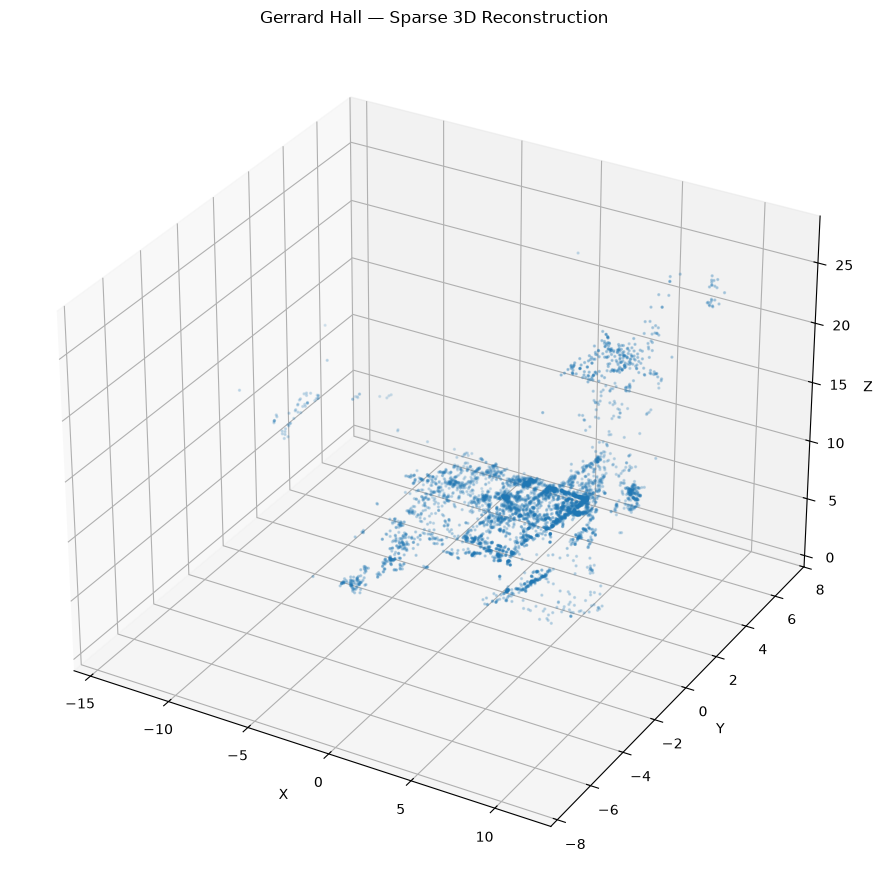

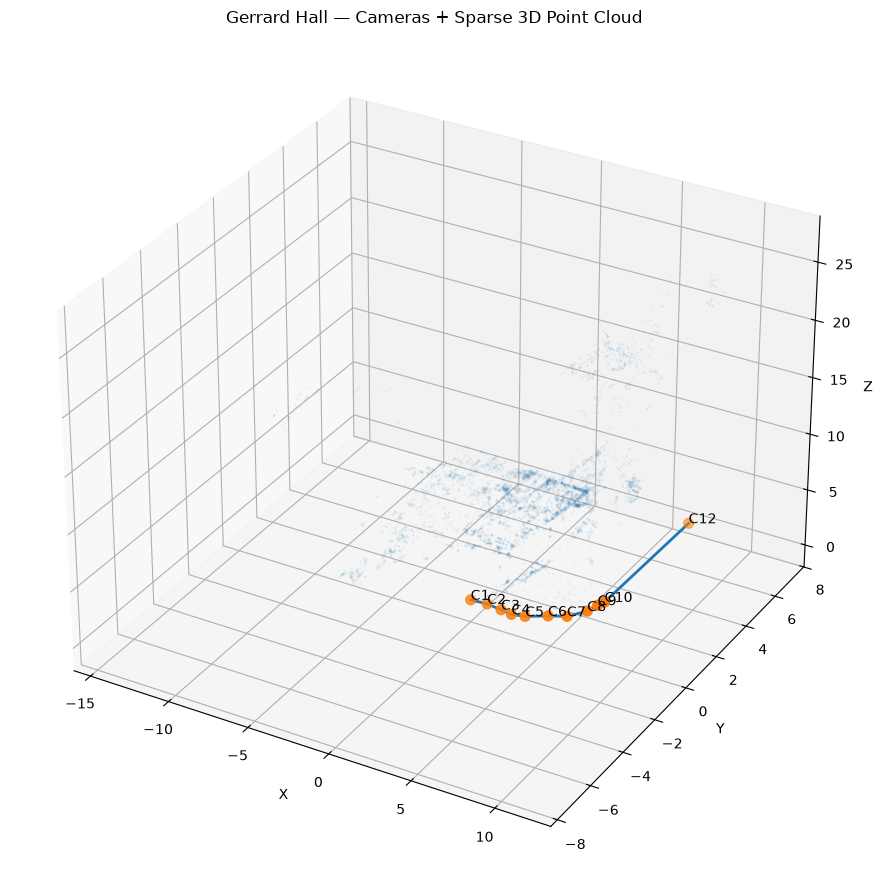


Camera trajectory:
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 9.98979400e-01  3.97590449e-02  2.14330618e-02]
 [ 1.94229554e+00 -3.58970486e-02  6.88933492e-03]
 [ 2.65308512e+00 -9.50333476e-02 -1.69474994e-02]
 [ 3.42739944e+00 -1.87160305e-02  4.10063448e-02]
 [ 4.70964698e+00  1.23736784e-01  4.52899337e-01]
 [ 5.82253183e+00  1.79800775e-01  8.25314802e-01]
 [ 6.85103016e+00  3.96042725e-01  1.45768644e+00]
 [ 7.32510218e+00  5.62288376e-01  1.95902139e+00]
 [ 7.66860513e+00  6.41986442e-01  2.29673150e+00]
 [ 8.13858084e+00  5.63012262e+00  2.93719096e+00]]

Reconstruction complete.


In [125]:
# ============================================================
# STEP 32 — GERRARD HALL 3D SPARSE POINT CLOUD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("GERRARD HALL — 3D SPARSE RECONSTRUCTION")
print("=" * 70)

# ------------------------------------------------------------
# Get reconstructed points
# ------------------------------------------------------------

points = np.asarray(points_3d_map).T

print("Total 3D points:", len(points))


# ------------------------------------------------------------
# Remove invalid points
# ------------------------------------------------------------

valid = np.isfinite(points).all(axis=1)

points = points[valid]

print("Valid 3D points:", len(points))


# ------------------------------------------------------------
# Remove extreme outliers
# ------------------------------------------------------------

center = np.median(points, axis=0)

distance = np.linalg.norm(
    points - center,
    axis=1
)

threshold = np.percentile(
    distance,
    98
)

points_clean = points[
    distance < threshold
]

print(
    "Points after outlier removal:",
    len(points_clean)
)


# ============================================================
# 3D POINT CLOUD
# ============================================================

fig = plt.figure(
    figsize=(12, 9)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    points_clean[:, 0],
    points_clean[:, 1],
    points_clean[:, 2],
    s=2,
    alpha=0.6
)

ax.set_title(
    "Gerrard Hall — Sparse 3D Reconstruction"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.tight_layout()

plt.show()


# ============================================================
# CAMERA TRAJECTORY
# ============================================================

fig = plt.figure(
    figsize=(12, 9)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)


# Plot point cloud

ax.scatter(
    points_clean[:, 0],
    points_clean[:, 1],
    points_clean[:, 2],
    s=1,
    alpha=0.25
)


# Camera centers

camera_indices = sorted(
    camera_poses.keys()
)

camera_centers = np.array(
    [
        camera_poses[i]["C"]
        for i in camera_indices
    ]
)


# Plot cameras

ax.scatter(
    camera_centers[:, 0],
    camera_centers[:, 1],
    camera_centers[:, 2],
    s=50
)


# Connect camera trajectory

ax.plot(
    camera_centers[:, 0],
    camera_centers[:, 1],
    camera_centers[:, 2],
    linewidth=2
)


# Label cameras

for i, C in zip(
    camera_indices,
    camera_centers
):

    ax.text(
        C[0],
        C[1],
        C[2],
        f"C{i+1}"
    )


ax.set_title(
    "Gerrard Hall — Cameras + Sparse 3D Point Cloud"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.tight_layout()

plt.show()


print("\nCamera trajectory:")
print(
    camera_centers
)

print("\nReconstruction complete.")